# 3 · Probabilités et mesure de la qualité — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch03_probabilites/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 3.1, 3.2, 3.3, 3.5, 3.6, 3.7 | vérifier tes exercices papier ✏️ | ✏️ | ★ à ★★ | |
| A | 3.12 | Dix mille fléchettes : estimer des aires (et π) | 🔬 | ★ | 15 |
|  | 3.13 | Deux disques : P(A\|B) = P(B\|A) ? | 🔮 | ★ | 10 |
|  | 3.14 | Penguins : espèce × île avec pd.crosstab | 📦 | ★★ | 20 |
| B | 3.15 | confusion_matrix à la manière de scikit-learn | 🔨 | ★★ | 20 |
|  | 3.16 | accuracy, precision, recall, F-beta et F1 (cas binaire) | 🔨 | ★★★ | 40 |
|  | 3.17 | La matrice à l'envers | 🐛 | ★★ | 15 |
|  | 3.18 | Tout positif, un seul positif : prédire les scores | 🔮 | ★★ | 15 |
|  | 3.19 | Le tableau de bord complet : classification_rates | 🔨 | ★★ | 20 |
| C | 3.20 | Un seuil sur la nageoire : precision et recall en balance | 🔬 | ★★ | 25 |
|  | 3.21 | Simuler le dépistage : la prévalence fait la precision | 🔬 | ★★ | 30 |
|  | 3.22 | Vérifier avec scikit-learn : classification_report et affichages | 📦 | ★★ | 20 |
|  | 3.23 | Lire la documentation de sklearn.metrics | 🛠️ | ★★ | 25 |
| D | 3.24 | Courbe ROC et AUC | 🔨 | ★★★ | 40 |
|  | 3.25 | Moyennes macro, micro et pondérée | 🔨 | ★★★ | 35 |
|  | 3.26 | Courbe precision-recall et average precision | 🔨 | ★★★ | 40 |
|  | 3.27 | ROC ou PR ? Lire les courbes d'un problème déséquilibré | 📈 | ★★ | 25 |
|  | 3.28 | Calibration : quand la météo annonce 70 % | 🔨 | ★★★ | 35 |
|  | 3.29 | Recall ≥ 0,99 au meilleur prix | 🏆 | ★★★ | 45 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        conflicts = subprocess.run(["git", "-C", str(DRIVE_DIR), "diff", "--name-only", "--diff-filter=U"],
                                   capture_output=True, text=True).stdout.split()
        if conflicts:  # a file changed outside mon_travail/ AND by Claude: git leaves conflict markers in it
            print("⚠️ Tes modifications de " + ", ".join(conflicts) + " (hors de mon_travail/) entrent en conflit "
                  "avec la nouvelle version ; elles sont gardées dans `git stash`. Pour reprendre la version du "
                  "dépôt : git restore --source=HEAD --staged --worktree <fichier> (00_setup/COLAB.md, « Problèmes "
                  "fréquents »).")
        elif pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Calculer des probabilités simples, conditionnelles, jointes et marginales, et ne pas confondre $P(A \mid B)$ avec $P(B \mid A)$.
- Construire une matrice de confusion et en tirer accuracy, precision, recall, F1 et les autres mesures, avec les conventions de scikit-learn.
- Choisir une mesure et un seuil selon le coût des erreurs et la prévalence.
- Évaluer des scores sur tous les seuils (courbes ROC et precision-recall) et vérifier des probabilités (calibration).

**Rappel express.** $P(A \mid B) = \frac{P(A, B)}{P(B)}$ ; $P(A, B) = P(A \mid B)\,P(B)$ ; matrice de confusion de scikit-learn pour des labels 0/1 : `[[TN, FP], [FN, TP]]` ; accuracy $= \frac{TP + TN}{n}$ ; precision $= \frac{TP}{TP + FP}$ ; recall $= \frac{TP}{TP + FN}$ ; spécificité $= \frac{TN}{TN + FP}$ ; $F_1 = \frac{2\,TP}{2\,TP + FP + FN}$. En Python : `pd.crosstab`, `sklearn.metrics.confusion_matrix`, `classification_report`, `roc_curve`, `precision_recall_curve`.

## Partie 0 · Vérifier tes exercices papier (✏️ 3.1, 3.2, 3.3, 3.5, 3.6 et 3.7)

Fais d'abord les exercices ✏️ de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse ici : **la valeur** que tu as trouvée (par exemple `42`, `0.125`, `[1, 2, 3]` ou `True`), pas l'expression Python, sinon tu ne vérifies rien. Arrondis comme l'énoncé le demande, et seulement à la fin du calcul. Les réponses pas encore remplies affichent ⏳. Les exercices ∂ 3.4 et 3.8 se corrigent avec `05_solutions.md`.

In [2]:
# The paper exercises only use the numbers of their statements (02_exercices.md)
import numpy as np

WALL = 4 * 2.5                                     # 3.1: area of the wall (m²)
AREA_A, AREA_B, AREA_AB = 2 * 1.5, 2 * 1, 1 * 1    # 3.1: rectangles A, B and their overlap
TRUTH_32 = np.array([0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0])   # 3.2
PRED_32 = np.array([0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0])
TP_32 = int(np.sum((TRUTH_32 == 1) & (PRED_32 == 1)))
FP_32 = int(np.sum((TRUTH_32 == 0) & (PRED_32 == 1)))
FN_32 = int(np.sum((TRUTH_32 == 1) & (PRED_32 == 0)))
TN_32 = int(np.sum((TRUTH_32 == 0) & (PRED_32 == 0)))
ICE = np.array([[42, 18], [38, 52]])              # 3.3: rows vanilla, chocolate; columns cone, cup
TP_35, FN_35, FP_35, TN_35 = 40, 10, 60, 890      # 3.5: fraud detector, 1 000 transactions
SPECIES_36 = np.array([[41, 3, 1], [7, 13, 0], [0, 2, 33]])   # 3.6: rows truth, columns prediction


def rates(tp, fn, fp, tn):
    """Every measure of a binary confusion matrix (3.5)."""
    n = tp + fn + fp + tn
    precision, recall = tp / (tp + fp), tp / (tp + fn)
    specificity, npv = tn / (tn + fp), tn / (tn + fn)
    return {"prevalence": (tp + fn) / n, "accuracy": (tp + tn) / n, "precision": precision, "recall": recall,
            "specificity": specificity, "npv": npv, "fpr": fp / (fp + tn), "fnr": fn / (fn + tp),
            "fdr": fp / (fp + tp), "for": fn / (fn + tn), "f1": 2 * tp / (2 * tp + fp + fn),
            "balanced": (recall + specificity) / 2,
            "mcc": (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))}


R35 = rates(TP_35, FN_35, FP_35, TN_35)
PRECISION_36 = np.diag(SPECIES_36) / SPECIES_36.sum(axis=0)
RECALL_36 = np.diag(SPECIES_36) / SPECIES_36.sum(axis=1)
F1_36 = 2 * PRECISION_36 * RECALL_36 / (PRECISION_36 + RECALL_36)
SUPPORT_36 = SPECIES_36.sum(axis=1)


def screening(n, prevalence, sensitivity, specificity):
    """Expected counts of a screening test (natural frequencies): TP, FN, FP, TN (3.7)."""
    sick = n * prevalence
    healthy = n - sick
    return sensitivity * sick, (1 - sensitivity) * sick, (1 - specificity) * healthy, specificity * healthy


TP_37, FN_37, FP_37, TN_37 = screening(50_000, 0.01, 0.99, 0.99)
BOOK = screening(10_000, 0.01, 0.99, 0.98)        # 3.7 part 2: the book's test (§3.8)

**Ex 3.1 — Fléchettes et aires : probabilités simples et conditionnelles**

In [3]:
wb.record("3.1a", AREA_A / WALL, decimals=2, mistakes={"c'est l'aire de A : divise-la par l'aire du mur": AREA_A})
wb.record("3.1b", AREA_B / WALL, decimals=2, mistakes={"c'est l'aire de B : divise-la par l'aire du mur": AREA_B})
wb.record("3.1c", AREA_AB / WALL, decimals=2, mistakes={"c'est P(A) × P(B) : ce produit ne vaut P(A, B) que si A et B sont indépendants ; mesure plutôt l'aire de la partie commune": (AREA_A / WALL) * (AREA_B / WALL), "c'est l'aire de la partie commune : divise-la par l'aire du mur": AREA_AB, "vérifie les bornes de la partie commune : pour chaque coordonnée, garde le plus grand des deux minimums et le plus petit des deux maximums": 1 * 1.5 / WALL})
wb.record("3.1d", AREA_AB / AREA_B, decimals=2, mistakes={"c'est P(B | A) : ici, on sait que la fléchette est dans B, divise par l'aire de B": AREA_AB / AREA_A, "c'est P(A, B) : sachant B, on divise par l'aire de B, pas par celle du mur": AREA_AB / WALL})
wb.record("3.1e", AREA_AB / AREA_A, decimals=3, mistakes={"c'est P(A | B) : ici, on sait que la fléchette est dans A, divise par l'aire de A": AREA_AB / AREA_B, "c'est P(A, B) : sachant A, on divise par l'aire de A, pas par celle du mur": AREA_AB / WALL})
wb.record("3.1f", 1 - (AREA_A + AREA_B - AREA_AB) / WALL, decimals=2, mistakes={"la partie commune est comptée deux fois dans P(A) + P(B) : P(A ou B) = P(A) + P(B) − P(A, B)": 1 - (AREA_A + AREA_B) / WALL, "c'est P(A ou B) : on demande l'événement contraire, ni A ni B": (AREA_A + AREA_B - AREA_AB) / WALL, "(1 − P(A)) × (1 − P(B)) n'est juste que si A et B sont indépendants, ce que rien ne garantit ici (tu le vérifieras en j) : passe par P(A ou B)": (1 - AREA_A / WALL) * (1 - AREA_B / WALL)})
wb.record("3.1g", round(400 * AREA_B / WALL), mistakes={"c'est le nombre attendu dans A et B à la fois": round(400 * AREA_AB / WALL), "c'est le nombre attendu dans A": round(400 * AREA_A / WALL)})
wb.record("3.1h", round(400 * AREA_AB / WALL), mistakes={"c'est le nombre attendu dans B : on demande A et B à la fois": round(400 * AREA_B / WALL)})
wb.record("3.1i", 41 / 76, decimals=3, mistakes={"sachant B : divise par le nombre de fléchettes dans B, pas par toutes": 41 / 400, "divise les fléchettes dans A et B par celles dans B, pas l'inverse": 76 / 41})
wb.record("3.1j", bool(np.isclose(AREA_AB / WALL, (AREA_A / WALL) * (AREA_B / WALL))), mistakes={"compare P(A, B) au produit P(A) × P(B)": True})

WB_ANSWER {"decimals": 2, "hash": "adee4b45bf32a79824d87508647ff796f1cd5c87b1b7e65863f7dcfe8d1202e6", "hash_coarse": "a2162fa7d213ddd7f0b2bf4d3fa9e192d6b29183236b3bca2f0ddd1b0e076e4a", "id": "3.1a", "kind": "float", "magnitude": -1, "mistakes": {"e7903c20aa76e96ea32532d84e4d62c3366648d0cc1d0bf75264596fd3ed112f": "c'est l'aire de A : divise-la par l'aire du mur"}, "sign": 1}
📝 Ex 3.1a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "796049172a19f6375a44c96deb6acc722a106c1f94d8ca1f2f565c47eb4e456b", "hash_coarse": "899c0a59a2a06ecef02be72b9a22e221789801b67b664475750ac89b460f2988", "id": "3.1b", "kind": "float", "magnitude": -1, "mistakes": {"046221996f883b39e2eddd4e0f69a383dc20cf2c21a68d738a6bb1d0ad845d80": "c'est l'aire de B : divise-la par l'aire du mur"}, "sign": 1}
📝 Ex 3.1b : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "9678a63db93db5e80edfe0ef04ec56d1167b339d3133d363f00f078cb7aa1038", "hash_coarse": "91c4e8ac33f7722e

**Ex 3.2 — Les 20 points : matrice de confusion et quatre mesures**

In [4]:
wb.record("3.2a", TP_32, mistakes={"ça, c'est le nombre de faux positifs : un vrai positif est positif ET prédit positif": FP_32, "c'est le nombre total de positifs : ne compte que ceux qui sont aussi prédits positifs": 10, "ça, c'est le nombre de vrais négatifs : un vrai positif est positif ET prédit positif": TN_32})
wb.record("3.2b", FP_32, mistakes={"ça, c'est le nombre de faux négatifs : un faux positif est un NÉGATIF prédit positif": FN_32})
wb.record("3.2c", FN_32, mistakes={"ça, c'est le nombre de faux positifs : un faux négatif est un POSITIF prédit négatif": FP_32})
wb.record("3.2d", TN_32, mistakes={"c'est le nombre total de négatifs : ne compte que ceux qui sont aussi prédits négatifs": 10, "ça, c'est le nombre de vrais positifs : un vrai négatif est négatif ET prédit négatif": TP_32})
wb.record("3.2e", [[TN_32, FP_32], [FN_32, TP_32]], mistakes={"c'est la disposition du livre (TP en haut à gauche) ; scikit-learn trie les labels, 0 puis 1, donc la ligne de la vérité 0 vient d'abord": [[TP_32, FN_32], [FP_32, TN_32]], "vérité en LIGNES, prédiction en COLONNES : ta matrice est transposée": [[TN_32, FN_32], [FP_32, TP_32]]})
wb.record("3.2f", (TP_32 + TN_32) / 20, decimals=2, mistakes={"l'accuracy compte les DEUX sortes de bonnes réponses, TP et TN": TP_32 / 20, "c'est le recall : l'accuracy compte les bonnes réponses, TP + TN, parmi les 20 points": TP_32 / (TP_32 + FN_32), "c'est la precision : l'accuracy compte les bonnes réponses, TP + TN, parmi les 20 points": TP_32 / (TP_32 + FP_32)})
wb.record("3.2g", TP_32 / (TP_32 + FP_32), decimals=3, mistakes={"c'est le recall : la precision divise par le nombre de prédictions positives, TP + FP": TP_32 / (TP_32 + FN_32)})
wb.record("3.2h", TP_32 / (TP_32 + FN_32), decimals=2, mistakes={"c'est la precision : le recall divise par le nombre de positifs réels, TP + FN": TP_32 / (TP_32 + FP_32), "c'est l'accuracy : le recall ne regarde que les positifs réels, TP + FN": (TP_32 + TN_32) / 20})
wb.record("3.2i", 2 * TP_32 / (2 * TP_32 + FP_32 + FN_32), decimals=3, mistakes={"c'est la moyenne ordinaire de la precision et du recall : le F1 est leur moyenne HARMONIQUE": (TP_32 / (TP_32 + FP_32) + TP_32 / (TP_32 + FN_32)) / 2, "deux causes possibles : tu as calculé avec la precision arrondie à 3 décimales, ou tu as tronqué au lieu d'arrondir au plus proche ; garde la fraction exacte jusqu'au bout (ou la forme 2 TP / (2 TP + FP + FN)), puis arrondis au plus proche": 0.666})

WB_ANSWER {"hash": "cd099ca46bbf1ec63eb2d7a535c8b237c62537a88a042f2235ff6d777db48a11", "id": "3.2a", "kind": "int", "magnitude": 0, "mistakes": {"8b083a362cc7162cd36a09bcdf4ce97cc93054277010b9f2688ea80cb91c466e": "ça, c'est le nombre de faux positifs : un vrai positif est positif ET prédit positif", "9c0fbc2400b50e3098841e8ec0b121ae531845c4f6e44641171370b3e5626d72": "c'est le nombre total de positifs : ne compte que ceux qui sont aussi prédits positifs", "c6e0a5708efb0ee04de60a6b75ceaf9f134f4f9f475f6f179c1934f2933c0b26": "ça, c'est le nombre de vrais négatifs : un vrai positif est positif ET prédit positif"}, "sign": 1}
📝 Ex 3.2a : réponse enregistrée (int).
WB_ANSWER {"hash": "af62043631e0148bdc88d6da2f5e8cc3d8e0e338cc7156ed93ba98e7e3b80241", "id": "3.2b", "kind": "int", "magnitude": 0, "mistakes": {"4f94137f77cbb27c4720366e0fb452c36fb779f513fe1c43c44e7941cc0112d6": "ça, c'est le nombre de faux négatifs : un faux positif est un NÉGATIF prédit positif"}, "sign": 1}
📝 Ex 3.2b : réponse 

**Ex 3.3 — Le glacier : jointes, marginales et conditionnelles**

In [5]:
wb.record("3.3a", ICE[0].sum() / ICE.sum(), decimals=2, mistakes={"c'est un effectif : divise par le nombre de clients": int(ICE[0].sum())})
wb.record("3.3b", ICE[:, 0].sum() / ICE.sum(), decimals=3, mistakes={"c'est la probabilité d'un pot : C est l'événement « cornet »": ICE[:, 1].sum() / ICE.sum()})
wb.record("3.3c", ICE[0, 0] / ICE.sum(), decimals=2, mistakes={"c'est P(V | C) : la probabilité jointe divise par le nombre total de clients": ICE[0, 0] / ICE[:, 0].sum(), "c'est P(C | V) : la probabilité jointe divise par le nombre total de clients": ICE[0, 0] / ICE[0].sum(), "c'est P(V) × P(C) : ce produit ne vaut P(V, C) que si V et C sont indépendants ; lis plutôt la case de la table": (ICE[0].sum() / ICE.sum()) * (ICE[:, 0].sum() / ICE.sum())})
wb.record("3.3d", ICE[0, 0] / ICE[:, 0].sum(), decimals=3, mistakes={"c'est P(C | V) : sachant C (un cornet), divise par le nombre de cornets": ICE[0, 0] / ICE[0].sum(), "c'est P(V, C) : sachant C, divise par le nombre de cornets, pas de clients": ICE[0, 0] / ICE.sum()})
wb.record("3.3e", ICE[0, 0] / ICE[0].sum(), decimals=2, mistakes={"c'est P(V | C) : sachant V (vanille), divise par le nombre de clients vanille": ICE[0, 0] / ICE[:, 0].sum(), "c'est P(V, C) : sachant V, divise par le nombre de clients vanille": ICE[0, 0] / ICE.sum()})
wb.record("3.3f", ICE[1, 1] / ICE[:, 1].sum(), decimals=3, mistakes={"c'est P(pot | chocolat) : sachant « pot », divise par le nombre de pots": ICE[1, 1] / ICE[1].sum(), "c'est la probabilité jointe : sachant « pot », divise par le nombre de pots": ICE[1, 1] / ICE.sum()})
wb.record("3.3g", bool(np.isclose(ICE[0, 0] / ICE.sum(), (ICE[0].sum() / ICE.sum()) * (ICE[:, 0].sum() / ICE.sum()))), mistakes={"compare P(V, C) au produit P(V) × P(C)": True})
wb.record("3.3h", round(300 * ICE[0, 0] / ICE.sum()), mistakes={"c'est le nombre d'hier, pour 150 clients : demain, ils seront 300": int(ICE[0, 0])})

WB_ANSWER {"decimals": 2, "hash": "367e2c491c5a1c543dd801cdb1b8747af099c3e37517306472d94365809100b8", "hash_coarse": "e7d9fd84dde728efbbc68d1781824f19d4443882c7c0f09ebadc484c51efa53d", "id": "3.3a", "kind": "float", "magnitude": -1, "mistakes": {"cc9bd2866713a932cb937fe631eb400b0ed95ae855923a8cb0b83d8ee1dc58f6": "c'est un effectif : divise par le nombre de clients"}, "sign": 1}
📝 Ex 3.3a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "228b5dac8b4547819d4e56c1b9e9b69a1bfbb63b534da2ca7a5d3fbf2ccbaab2", "hash_coarse": "2773d902f96ea74b7dd8dd110e9269a2e054acc64d4842cec8667c70d64b0634", "id": "3.3b", "kind": "float", "magnitude": -1, "mistakes": {"52ba041dfd5596fa9ff6b527cd0a5a7d17a43fed34e260bcda872fd394b0b16d": "c'est la probabilité d'un pot : C est l'événement « cornet »"}, "sign": 1}
📝 Ex 3.3b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "0b199dfe47066f392dda35d34c2a9f4c01784dcfddef076636b4c61f6ab5ee40", "hash_coarse": 

**Ex 3.5 — Toutes les mesures du tableau récapitulatif**

In [6]:
wb.record("3.5a", R35["prevalence"], decimals=3, mistakes={"c'est la part de prédictions positives : la prévalence compte les positifs réels (la vérité), TP + FN": (TP_35 + FP_35) / 1000})
wb.record("3.5b", R35["accuracy"], decimals=3, mistakes={"l'accuracy compte les DEUX sortes de bonnes réponses, TP et TN": TP_35 / 1000})
wb.record("3.5c", R35["precision"], decimals=3, mistakes={"c'est le recall : la precision divise par les prédictions positives, TP + FP": R35["recall"]})
wb.record("3.5d", R35["recall"], decimals=3, mistakes={"c'est la precision : le recall divise par les positifs réels, TP + FN": R35["precision"]})
wb.record("3.5e", R35["specificity"], decimals=3, mistakes={"c'est la NPV : la spécificité divise par le nombre de négatifs RÉELS, TN + FP": R35["npv"], "c'est le FPR, son complément à 1": R35["fpr"]})
wb.record("3.5f", R35["npv"], decimals=3, mistakes={"c'est la spécificité : la NPV divise par le nombre de prédictions négatives, TN + FN": R35["specificity"], "c'est le FOR, son complément à 1": R35["for"]})
wb.record("3.5g", R35["fpr"], decimals=3, mistakes={"c'est le FDR : le FPR divise par le nombre de négatifs réels, FP + TN": R35["fdr"], "c'est la spécificité, son complément à 1": R35["specificity"], "tu as divisé par les 1 000 transactions : le FPR divise par les négatifs réels, FP + TN": FP_35 / 1000})
wb.record("3.5h", R35["fnr"], decimals=3, mistakes={"c'est le FOR : le FNR divise par le nombre de positifs réels, FN + TP": R35["for"], "c'est le recall, son complément à 1": R35["recall"]})
wb.record("3.5i", R35["fdr"], decimals=3, mistakes={"c'est le FPR : le FDR divise par le nombre de prédictions positives, FP + TP": R35["fpr"], "c'est la precision, son complément à 1": R35["precision"]})
wb.record("3.5j", R35["for"], decimals=3, mistakes={"c'est le FNR : le FOR divise par le nombre de prédictions négatives, FN + TN": R35["fnr"], "c'est la NPV, son complément à 1": R35["npv"], "tu as divisé par les 1 000 transactions : le FOR divise par les prédictions négatives, FN + TN": FN_35 / 1000})
wb.record("3.5k", R35["f1"], decimals=3, mistakes={"c'est la moyenne ordinaire de la precision et du recall : le F1 est leur moyenne HARMONIQUE": (R35["precision"] + R35["recall"]) / 2})
wb.record("3.5l", R35["balanced"], decimals=3, mistakes={"c'est l'accuracy : la balanced accuracy est la moyenne du recall et de la spécificité": R35["accuracy"], "tu as fait la moyenne avec une spécificité déjà arrondie : garde la fraction exacte jusqu'au bout, puis arrondis": 0.869})
wb.record("3.5m", R35["mcc"], decimals=3, mistakes={"le dénominateur est la RACINE CARRÉE du produit des quatre sommes": (TP_35 * TN_35 - FP_35 * FN_35) / ((TP_35 + FP_35) * (TP_35 + FN_35) * (TN_35 + FP_35) * (TN_35 + FN_35))})

WB_ANSWER {"decimals": 3, "hash": "7d20e31ab551298d68b98513e37e79243d53260c946da7c24a29c5bc4940944d", "hash_coarse": "b312899b99ac63b886a6519f98d117a998db6dc15c605fe7ebadaf26dd17aec8", "id": "3.5a", "kind": "float", "magnitude": -2, "mistakes": {"eaa3d47c0504b18aafe8c0573288b040c9f400fa216dc6aab106263da1ea6dbb": "c'est la part de prédictions positives : la prévalence compte les positifs réels (la vérité), TP + FN"}, "sign": 1}
📝 Ex 3.5a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "fa8e5784ac97ddd5f265053b49a859298394c67e87ca6bc239e9817bd3a51a6c", "hash_coarse": "0f0b925ff46ab5a84725c1170bbb217114806f9c3b97cb2222ce1bd512c0ad33", "id": "3.5b", "kind": "float", "magnitude": -1, "mistakes": {"624df273df64bdbe7597d00350850ba6012e84ddf1699662513b229126d9703e": "l'accuracy compte les DEUX sortes de bonnes réponses, TP et TN"}, "sign": 1}
📝 Ex 3.5b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "df97f1c13ef8782c4e7ca6ece97168

**Ex 3.6 — Trois espèces : moyennes macro, micro et pondérée**

In [7]:
wb.record("3.6a", SUPPORT_36.tolist(), mistakes={"ce sont les nombres de PRÉDICTIONS de chaque espèce (totaux des colonnes) : le support compte les vrais manchots de chaque espèce (totaux des lignes)": SPECIES_36.sum(axis=0).tolist()})
wb.record("3.6b", PRECISION_36.tolist(), decimals=3, mistakes={"ce sont les recalls : la precision d'une espèce divise par le total de sa COLONNE (les prédictions)": RECALL_36.tolist()})
wb.record("3.6c", RECALL_36.tolist(), decimals=3, mistakes={"ce sont les precisions : le recall d'une espèce divise par le total de sa LIGNE (les vrais manchots)": PRECISION_36.tolist()})
wb.record("3.6d", F1_36.tolist(), decimals=3, mistakes={"ce sont des moyennes ordinaires : le F1 est la moyenne HARMONIQUE de la precision et du recall": ((PRECISION_36 + RECALL_36) / 2).tolist()})
wb.record("3.6e", PRECISION_36.mean(), decimals=3, mistakes={"c'est la precision pondérée : la moyenne macro est la moyenne SIMPLE des trois espèces": np.average(PRECISION_36, weights=SUPPORT_36), "c'est la precision micro, qui vaut l'accuracy": np.trace(SPECIES_36) / SPECIES_36.sum()})
wb.record("3.6f", F1_36.mean(), decimals=3, mistakes={"c'est le F1 pondéré : la moyenne macro est la moyenne SIMPLE des trois espèces": np.average(F1_36, weights=SUPPORT_36), "c'est le F1 micro, qui vaut l'accuracy": np.trace(SPECIES_36) / SPECIES_36.sum(), "c'est le F1 de la precision macro et du recall macro : fais plutôt la moyenne des trois F1": 2 * PRECISION_36.mean() * RECALL_36.mean() / (PRECISION_36.mean() + RECALL_36.mean())})
wb.record("3.6g", np.average(F1_36, weights=SUPPORT_36), decimals=3, mistakes={"c'est le F1 macro : la moyenne pondérée multiplie le F1 de chaque espèce par son support": F1_36.mean(), "c'est une moyenne pondérée par les PRÉDICTIONS : le poids d'une espèce est son support (vrais manchots)": np.average(F1_36, weights=SPECIES_36.sum(axis=0)), "tu as fait la moyenne des F1 arrondis de d : repars des fractions exactes des trois F1 et n'arrondis qu'à la fin": 0.869, "c'est le F1 micro, qui vaut l'accuracy : le F1 pondéré fait la moyenne des F1 des espèces, pondérée par leur support": np.trace(SPECIES_36) / SPECIES_36.sum()})
wb.record("3.6h", np.trace(SPECIES_36) / SPECIES_36.sum(), decimals=3, mistakes={"c'est le F1 macro : le F1 micro additionne d'abord les TP, FP et FN des trois espèces": F1_36.mean(), "c'est le F1 pondéré : le F1 micro additionne d'abord les TP, FP et FN des trois espèces": np.average(F1_36, weights=SUPPORT_36)})

WB_ANSWER {"decimals": 0, "element_hashes": ["d19327cae38b42b375ba13cf5ab0f2cc70a2884da4049123c09bc951ddbc1dce", "f7aed9c94bc8303520bf02d2d5b98e44d8748a1952e4b703ee1ab879a5f1f075", "8704c4db430097d1a2c9f8dbc29f31dcdf1563e4f9d0c0a1ddd9865820fef4ef"], "hash": "188b1e2b56178967fcf335600ec514cb4337ba137ade1727571c9905aa9282be", "id": "3.6a", "integer": true, "kind": "array", "mistakes": {"a888f759c7faa7129457f4dffa53a047ff83f5d6b82aa35face7494849e25423": "ce sont les nombres de PRÉDICTIONS de chaque espèce (totaux des colonnes) : le support compte les vrais manchots de chaque espèce (totaux des lignes)"}, "shape": [3]}
📝 Ex 3.6a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 3, "element_coarse": [["ab860fac9bbefdf97e12529152d9ccda9e99ca4f7c9b396aa6fd80ec046f8150"], ["a88084de953541343b118cc9b36125fa42a53e164cdee71c953efc3f81dfd490"], ["c96498749dbdb54ca76e88c365abd84c340660044ad25c4d4f9732cf8cc0b12e"]], "element_hashes": ["8d158ad257b1b7f16f393583759bbffa83022a2b7efd7

**Ex 3.7 — Le test « fiable à 99 % » dans une ville à 1 % de malades**

In [8]:
wb.record("3.7a", round(50_000 * 0.01))
wb.record("3.7b", round(TP_37), mistakes={"c'est le nombre de malades : le test n'en détecte que 99 %": round(50_000 * 0.01), "c'est 99 % de toute la ville (et aussi le nombre de personnes saines) : les vrais positifs sont les MALADES que le test détecte, 99 % des seuls malades": round(0.99 * 50_000)})
wb.record("3.7c", round(FN_37), mistakes={"c'est le nombre de faux positifs : un faux négatif est un MALADE déclaré négatif": round(FP_37), "c'est 1 % de toute la ville (ou le nombre de malades) : les faux négatifs sont 1 % des seuls MALADES": round(0.01 * 50_000)})
wb.record("3.7d", round(FP_37), mistakes={"le taux de 1 % de faux positifs s'applique aux 49 500 personnes SAINES, pas à toute la ville": round(0.01 * 50_000), "c'est le nombre de faux négatifs : un faux positif est une personne SAINE déclarée positive": round(FN_37)})
wb.record("3.7e", round(TN_37), mistakes={"les vrais négatifs sont 99 % des personnes SAINES (49 500), pas de toute la ville": round(0.99 * 50_000)})
wb.record("3.7f", TP_37 / (TP_37 + FP_37), decimals=2, mistakes={"c'est la sensibilité P(positif | malade) : la precision est P(malade | positif), divise TP par le nombre de positifs": 0.99})
wb.record("3.7g", TN_37 / (TN_37 + FN_37), decimals=4, mistakes={"c'est la spécificité P(négatif | sain) : la NPV divise TN par le nombre de résultats négatifs": 0.99})
wb.record("3.7h", (TP_37 + TN_37) / 50_000, decimals=2, mistakes={"c'est la precision : l'accuracy compte les bonnes réponses parmi TOUTES les personnes": TP_37 / (TP_37 + FP_37), "c'est la NPV : l'accuracy compte les bonnes réponses, TP + TN, parmi les 50 000 habitants": TN_37 / (TN_37 + FN_37)})
wb.record("3.7i", screening(50_000, 0.002, 0.99, 0.99)[0] / (screening(50_000, 0.002, 0.99, 0.99)[0] + screening(50_000, 0.002, 0.99, 0.99)[2]), decimals=3, mistakes={"c'est la sensibilité : la precision dépend aussi de la prévalence ; refais l'arbre avec 100 malades": 0.99, "deux causes possibles : les faux positifs sont 1 % des personnes SAINES de cette ville, pas de tous ses habitants ; ou bien tu as tronqué au lieu d'arrondir au plus proche": 99 / (99 + 500)})
wb.record("3.7j", screening(50_000, 0.10, 0.99, 0.99)[0] / (screening(50_000, 0.10, 0.99, 0.99)[0] + screening(50_000, 0.10, 0.99, 0.99)[2]), decimals=3, mistakes={"c'est la sensibilité : la precision dépend aussi de la prévalence ; refais l'arbre avec 5 000 malades": 0.99, "les faux positifs sont 1 % des personnes SAINES de cette ville, pas de tous ses habitants": 4950 / (4950 + 500)})
wb.record("3.7k", BOOK[3] / (BOOK[3] + BOOK[2]), decimals=2, mistakes={"c'est la NPV : la spécificité divise TN par le nombre de personnes SAINES, TN + FP": BOOK[3] / (BOOK[3] + BOOK[1]), "ce test n'est pas celui de la partie 1 : calcule TN / (TN + FP) avec les comptages du livre": 0.99, "tu as divisé TN par toute la ville : la spécificité divise par les personnes SAINES, TN + FP": BOOK[3] / 10_000})
wb.record("3.7l", BOOK[3] / (BOOK[3] + BOOK[1]), decimals=4, mistakes={"c'est la spécificité : la NPV divise TN par le nombre de résultats NÉGATIFS, TN + FN": BOOK[3] / (BOOK[3] + BOOK[2])})

WB_ANSWER {"hash": "924dcb0782396abf18adb2ac5b6714d49c364aeb63914c93ecf2dfcc6f414157", "id": "3.7a", "kind": "int", "magnitude": 2, "sign": 1}
📝 Ex 3.7a : réponse enregistrée (int).
WB_ANSWER {"hash": "4f0eba28dea861bd373624b27c8346f98817c333b1efa94328c63757712a6078", "id": "3.7b", "kind": "int", "magnitude": 2, "mistakes": {"b426298b3ef8ed44bc79bc1c0bee63a690d9e45a9b00000ca78d9ede6471a8c2": "c'est 99 % de toute la ville (et aussi le nombre de personnes saines) : les vrais positifs sont les MALADES que le test détecte, 99 % des seuls malades", "b9e1d701d4d5e8377222208591fd69b1364a346dd5a4d6885350360e9007631e": "c'est le nombre de malades : le test n'en détecte que 99 %"}, "sign": 1}
📝 Ex 3.7b : réponse enregistrée (int).
WB_ANSWER {"hash": "59fa531013720995b524f297eb6d723e66ef48a77a5b8508a38453d21a1d214b", "id": "3.7c", "kind": "int", "magnitude": 0, "mistakes": {"d9b09c50020235c2f3781ca5ae5ff2ba4c798e26755c66012ff9a62edcb87c5e": "c'est le nombre de faux positifs : un faux négatif est 

## Partie A · Probabilités par les aires et par les tables

Fiche §3.2 à §3.6. Tu estimes une aire en lançant des fléchettes simulées, tu vérifies quand $P(A \mid B)$ et $P(B \mid A)$ diffèrent, puis tu lis des probabilités jointes, marginales et conditionnelles dans une table de contingence des manchots. La cellule ci-dessous charge les données et les outils de tout le notebook : exécute-la d'abord.

In [9]:
# Tools and data for the notebook exercises (parts A to D)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import metrics as skm

penguins = wb.datasets.load_penguins()                    # the 344 penguins
MEASURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
measured = penguins.dropna(subset=MEASURES).reset_index(drop=True)   # the 342 penguins with their 4 measures
species = measured["species"].to_numpy()                  # their true species
flipper = measured["flipper_length_mm"].to_numpy()        # in mm (whole numbers)
is_gentoo = (species == "Gentoo").astype(int)             # 1 = Gentoo, 0 = another species (3.20, 3.24)


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def fr(value, decimals=2):
    """A number written the French way, for the messages: fr(0.25) -> '0,25'."""
    return f"{value:.{decimals}f}".replace(".", ",")


def run_metrics_tests(keyword, impl="learner"):
    """Run the tests of mylearn.metrics selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", "tests/test_ch03_metrics.py", "-k", keyword, "-q",
               "-p", "no:cacheprovider", "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix("FAILED tests/test_ch03_metrics.py::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


def error_name(func, *args, **kwargs):
    """Name of the exception raised by func(*args, **kwargs), or "no error"."""
    try:
        func(*args, **kwargs)
    except NotImplementedError:
        raise
    except Exception as error:  # noqa: BLE001 - we want the name of whatever is raised
        return type(error).__name__
    return "no error"


print(f"{len(penguins)} penguins, {len(measured)} with their 4 measures")

344 penguins, 342 with their 4 measures


### Ex 3.12 — Dix mille fléchettes : estimer des aires (et π) 🔬 ★ ⏱️ 15 min
**Objectif :** estimer une aire en comptant des fléchettes simulées, et mesurer comment l'erreur diminue avec le nombre de lancers.  
**Prérequis :** ch. 2 (loi uniforme, graine, écart-type, vitesse en $1/\sqrt{n}$) · fiche §3.2, §3.3 · livre §3.2, §3.3 · **Fil rouge :** synthétique · **Parcours :** M, C

Le mur est un carré de 2 m de côté, avec un disque de rayon 1 m peint en son centre. Une fléchette tombe en un point $(x, y)$ tiré uniformément sur le mur (fiche §3.2) ; elle touche le disque si $(x - 1)^2 + (y - 1)^2 \le 1$. D'après la fiche, la probabilité de toucher le disque est le rapport de son aire, $\pi$, à celle du mur, 4 : compter les fléchettes dans le disque **estime** donc $\pi$.

Pour que tout le monde obtienne les mêmes nombres, tire les points **exactement** ainsi : `points = 2 * rng.random((n, 2))` (une ligne par fléchette, colonnes $x$ et $y$), avec le générateur `rng` indiqué.

a) `pi_hat_12` : avec `rng = np.random.default_rng(3)` et $n = 10\,000$ fléchettes, l'estimation $\hat{\pi} = 4 \times$ (part des fléchettes tombées dans le disque) (3 décimales).

Écris ensuite `estimate_pi(n, rng)`, qui fait la même chose pour $n$ fléchettes et renvoie un `float`. La vérification contrôle qu'elle redonne la bonne réponse de a) avec la graine 3, et qu'avec un million de fléchettes elle tombe à moins de 0,01 de $\pi$.

b) `spread_12` : crée **un seul** générateur, `rng = np.random.default_rng(12)`, puis calcule 200 estimations de 10 000 fléchettes chacune, l'une après l'autre avec ce même générateur (`[estimate_pi(10_000, rng) for _ in range(200)]`). Donne leur écart-type (`np.std`, 3 décimales) : c'est l'erreur typique d'une estimation.
c) `factor_12` : par combien faut-il multiplier le nombre de fléchettes pour diviser cette erreur typique par 10 ? (un entier ; souviens-toi de la vitesse en $1/\sqrt{n}$ du ch. 2). Une fois c) rempli, la vérification le mesure sur d'autres nombres de fléchettes.

In [10]:
rng = np.random.default_rng(3)
points = 2 * rng.random((10_000, 2))
in_disc = ((points - 1) ** 2).sum(axis=1) <= 1
pi_hat_12 = 4 * in_disc.mean()


def estimate_pi(n, rng):
    """Estimate pi with n darts thrown uniformly on the 2 m x 2 m wall: 4 x (share of darts in the disc)."""
    points = 2 * rng.random((n, 2))
    return float(4 * np.mean(((points - 1) ** 2).sum(axis=1) <= 1))


rng = np.random.default_rng(12)
estimates_12 = [estimate_pi(10_000, rng) for _ in range(200)]
spread_12 = float(np.std(estimates_12))
factor_12 = 100
print(pi_hat_12, spread_12, "mean of the 200 estimates:", np.mean(estimates_12))
rng_demo = np.random.default_rng(0)
for n_demo in [25, 250, 2_500]:
    spread_demo = np.std([estimate_pi(n_demo, rng_demo) for _ in range(500)])
    print(f"   {n_demo:>6} darts: typical error of an estimate ≈ {spread_demo:.4f}")

3.1484 0.017097261067200217 mean of the 200 estimates: 3.1392919999999997
       25 darts: typical error of an estimate ≈ 0.3303
      250 darts: typical error of an estimate ≈ 0.1064
     2500 darts: typical error of an estimate ≈ 0.0335


In [11]:
wb.record("3.12a", pi_hat_12, decimals=3, mistakes={"c'est la part des fléchettes dans le disque : multiplie-la par 4, le rapport de l'aire du mur (4) à celle d'un disque de rayon 1 (π)": in_disc.mean(),
                                                    "tire les points exactement comme l'énoncé, 2 * rng.random((10_000, 2)), une ligne par fléchette : un autre découpage des nombres (deux appels, ou la forme (2, n)) donne d'autres fléchettes": 4 * np.mean((2 * np.random.default_rng(3).random(10_000) - 1) ** 2 + (2 * np.random.default_rng(3).random(20_000)[10_000:] - 1) ** 2 <= 1)})
wb.record("3.12b", spread_12, decimals=3, mistakes={"ta réponse s'arrondit à 0 : soit tes 200 estimations sont identiques (crée le générateur UNE fois, avant la boucle, et passe le même à chaque appel, ch. 2), soit tu as donné leur variance (on demande l'écart-type, sa racine)": 0.0})
wb.record("3.12c", factor_12, mistakes={"10 fois plus de fléchettes ne divisent pas l'erreur typique par 10 : relis à quelle vitesse elle diminue quand n augmente (ch. 2)": 10})

WB_ANSWER {"decimals": 3, "hash": "40b3e88f1ec2bce9d8e26895284eeb5e8e651d03cca5752c09c872f114e7bbf4", "hash_coarse": "76bfb61ad739bf6bfa39b60f317947cd8b695444b6794d3c7e979ee604f48f14", "id": "3.12a", "kind": "float", "magnitude": 0, "mistakes": {"2e6bd0751116ce5566d09d8e1d2e4cf12650b7b1644862212049418e42bdebaa": "tire les points exactement comme l'énoncé, 2 * rng.random((10_000, 2)), une ligne par fléchette : un autre découpage des nombres (deux appels, ou la forme (2, n)) donne d'autres fléchettes", "876acab18ecc5f6d2943a2654fbb8436cd3cfaf8890318856934b0502b5dbad1": "c'est la part des fléchettes dans le disque : multiplie-la par 4, le rapport de l'aire du mur (4) à celle d'un disque de rayon 1 (π)"}, "sign": 1}
📝 Ex 3.12a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "d1915bd02a2215b122bac0df10915d14726d05ecdd1b7217b8b9f32f52e4214e", "hash_coarse": "804af15abdb2982ac1b2d591cf3a4594b002666d4570eae07bd629fb91717d82", "id": "3.12b", "kind": "float", "mag

💡 Une estimation par comptage est une variable aléatoire : elle fluctue autour de la vraie valeur, avec une erreur typique proportionnelle à $1/\sqrt{n}$. Diviser l'erreur par 10 coûte 100 fois plus de lancers : c'est la même loi que l'erreur typique d'une moyenne au ch. 2, et celle d'une accuracy mesurée sur un jeu de test (un jeu de test de 100 exemples donne une accuracy à ± 0,05 près environ). Estimer une aire par des tirages au hasard s'appelle une méthode de **Monte-Carlo** : elle marche pour des formes dont l'aire n'a pas de formule simple.

### Ex 3.13 — Deux disques : P(A|B) = P(B|A) ? 🔮 ★ ⏱️ 10 min
**Objectif :** prévoir quand $P(A \mid B)$ et $P(B \mid A)$ sont égales, puis le vérifier avec des fléchettes.  
**Prérequis :** Ex 3.12, Ex 3.1 · fiche §3.4 · livre §3.4 · **Fil rouge :** synthétique · **Parcours :** M, C

Un mur carré de 4 m de côté porte deux disques qui se chevauchent en partie : $A$, de rayon 0,5 m, et $B$, de rayon 1 m. **Sans rien exécuter**, prévois :
a) `prediction_3_13a` : laquelle est la plus grande, $P(A \mid B)$ ou $P(B \mid A)$ ? Réponds `1` si c'est $P(A \mid B)$, `-1` si c'est $P(B \mid A)$, `0` si elles sont égales ;
b) `prediction_3_13b` : même question si l'on agrandit $A$ jusqu'au rayon de $B$, les deux disques se chevauchant toujours en partie ;
c) `prediction_3_13c` : dans la situation de départ, le rapport $\frac{P(A \mid B)}{P(B \mid A)}$ (2 décimales). Écris les deux probabilités comme des rapports d'aires (fiche §3.4) : l'aire de la partie commune, difficile à calculer, n'est pas nécessaire.

Écris ton hypothèse (cellule 📝), puis tes trois prédictions ; la vérification ne regarde que tes prédictions. Ensuite seulement, exécute l'**Expérience** : 100 000 fléchettes.

In [12]:
prediction_3_13a, prediction_3_13b, prediction_3_13c = -1, 0, 0.25

In [13]:
wb.record("3.13a", prediction_3_13a, mistakes={"les deux probabilités ont le même numérateur, l'aire de la partie commune : compare leurs dénominateurs": 1,
                                                "elles ne sont égales que si leurs dénominateurs le sont : A et B ont-ils la même aire ?": 0})
wb.record("3.13b", prediction_3_13b, mistakes={"deux disques de même rayon ont la même aire : les deux probabilités ont alors le même numérateur ET le même dénominateur": 1,
                                                "même numérateur (la partie commune) et, maintenant, même dénominateur : l'aire de A est devenue celle de B": -1})
wb.record("3.13c", prediction_3_13c, decimals=2, mistakes={"c'est le rapport des rayons : une aire varie comme le CARRÉ du rayon": 0.5,
                                                            "c'est l'inverse : P(B | A) / P(A | B)": 4})

WB_ANSWER {"hash": "3dc4d272cdd83fa73b56d11eb05d9e1241e46c8d35c7aabc6f9e9bb41d022ca7", "id": "3.13a", "kind": "int", "magnitude": 0, "mistakes": {"1edb4b25d9776dd905d59241261c82d529865e7af8b92fa3f4a531adac56e684": "les deux probabilités ont le même numérateur, l'aire de la partie commune : compare leurs dénominateurs", "8ddfc13625aa0b81761656a8915f74f7b79110609514fbe4312e2a0600165014": "elles ne sont égales que si leurs dénominateurs le sont : A et B ont-ils la même aire ?"}, "sign": -1}
📝 Ex 3.13a : réponse enregistrée (int).
WB_ANSWER {"hash": "263cb8c71751346b53680daa4079c2d25393c005a3319d9109cd83206395b6f6", "id": "3.13b", "kind": "int", "magnitude": null, "mistakes": {"0a7939e0e12281b8944c314ebe6d1a9454d162d0fcee5e43d30b4ffdd234fc70": "même numérateur (la partie commune) et, maintenant, même dénominateur : l'aire de A est devenue celle de B", "46e1715f74d2240fcdfc7ccabf87002d25df649bf3f6a0d9804cfcbaeea2ed4c": "deux disques de même rayon ont la même aire : les deux probabilités ont

**Expérience** : exécute la cellule et compare avec tes prédictions.

darts in A: 4955 · in B: 19543 · in A and B: 4039
P(A | B) ≈ 0.207   P(B | A) ≈ 0.815


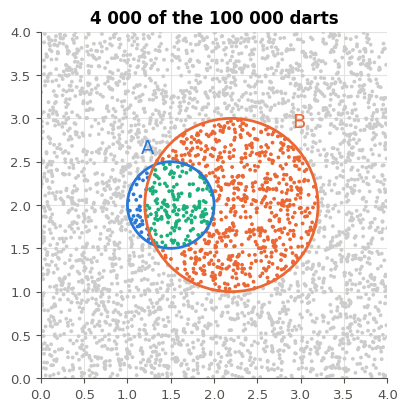

In [14]:
if any(answer is ... or answer is None for answer in [prediction_3_13a, prediction_3_13b, prediction_3_13c]):
    print("⏳ Ex 3.13 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    rng_13 = np.random.default_rng(13)
    darts_13 = 4 * rng_13.random((100_000, 2))                          # the 4 m x 4 m wall
    in_a = ((darts_13 - [1.5, 2.0]) ** 2).sum(axis=1) <= 0.5 ** 2      # disc A: centre (1.5, 2), radius 0.5
    in_b = ((darts_13 - [2.2, 2.0]) ** 2).sum(axis=1) <= 1.0 ** 2      # disc B: centre (2.2, 2), radius 1
    p_a_given_b = np.sum(in_a & in_b) / np.sum(in_b)
    p_b_given_a = np.sum(in_a & in_b) / np.sum(in_a)
    print(f"darts in A: {in_a.sum()} · in B: {in_b.sum()} · in A and B: {np.sum(in_a & in_b)}")
    print(f"P(A | B) ≈ {p_a_given_b:.3f}   P(B | A) ≈ {p_b_given_a:.3f}")

    shown = slice(0, 4000)                                              # 4 000 darts are enough for the picture
    colour = np.where(in_a & in_b, "C2", np.where(in_a, "C0", np.where(in_b, "C1", "0.8")))[shown]
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(*darts_13[shown].T, s=3, c=colour)
    ax.add_patch(plt.Circle((1.5, 2.0), 0.5, fill=False, color="C0", lw=2))
    ax.add_patch(plt.Circle((2.2, 2.0), 1.0, fill=False, color="C1", lw=2))
    ax.text(1.15, 2.6, "A", color="C0", fontsize=14)
    ax.text(2.9, 2.9, "B", color="C1", fontsize=14)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_aspect("equal")
    ax.set_title("4 000 of the 100 000 darts")
    plt.show()

d) `ratio_13` : le rapport mesuré $\frac{P(A \mid B)}{P(B \mid A)}$, calculé avec les variables de l'expérience (2 décimales). Compare-le à ta prédiction c. Dans tes notes : ce rapport d'estimations est exactement un rapport de deux comptages de fléchettes ; lesquels ?

In [15]:
ratio_13 = p_a_given_b / p_b_given_a
print(ratio_13, in_a.sum() / in_b.sum())

0.2535434682495011 0.2535434682495011


In [16]:
wb.record("3.13d", ratio_13, decimals=2, mistakes={"c'est P(B | A) / P(A | B) : inverse le rapport": 1 / ratio_13})

WB_ANSWER {"decimals": 2, "hash": "65fd06ecde44707e28ed396b047a6e2833d374c0b85a9b46fdedf625b79fc981", "hash_coarse": "38d0ccecfbd3782bfb8443041994ff6755527a09e34e48ae2608814aa31e67ed", "id": "3.13d", "kind": "float", "magnitude": -1, "mistakes": {"027444674bbf81b6e588f0fbe901ac742da7bc447d66db3381c0af2711042de4": "c'est P(B | A) / P(A | B) : inverse le rapport"}, "sign": 1}
📝 Ex 3.13d : réponse enregistrée (float, 2 décimale(s)).


💡 $P(A \mid B) = \frac{\text{aire}(A \cap B)}{\text{aire}(B)}$ et $P(B \mid A) = \frac{\text{aire}(A \cap B)}{\text{aire}(A)}$ : même numérateur, donc le rapport vaut $\frac{\text{aire}(A)}{\text{aire}(B)} = \frac{P(A)}{P(B)} = \left(\frac{0{,}5}{1}\right)^2$, quelle que soit la partie commune. Avec des fléchettes, le rapport des deux estimations vaut exactement (fléchettes dans A) / (fléchettes dans B) : le nombre de fléchettes dans la partie commune se simplifie. Les deux conditionnelles sont égales seulement si $P(A) = P(B)$ (ou si les disques ne se touchent pas : 0 = 0). C'est la règle du produit, $P(A \mid B)\,P(B) = P(B \mid A)\,P(A)$, que le ch. 4 transforme en règle de Bayes.

### Ex 3.14 — Penguins : espèce × île avec pd.crosstab 📦 ★★ ⏱️ 20 min
**Objectif :** lire des probabilités jointes, marginales et conditionnelles dans une table de contingence, et tester l'indépendance de deux variables.  
**Prérequis :** Ex 3.3, rappel 3.R3 · fiche §3.4 à §3.6 (🧮 Rappel outil : `pd.crosstab`) · **Fil rouge :** Penguins · **Parcours :** C

La fiche a croisé le sexe et l'espèce des manchots (§3.6). Fais de même avec l'**espèce** et l'**île**, pour les 344 manchots de `penguins` (aucune de ces deux colonnes ne manque).

a) `table_14` : la table de contingence (`pd.crosstab`), espèces en lignes, îles en colonnes, **sans** les marges ;
b) `p_gentoo_given_biscoe` : $P(\text{Gentoo} \mid \text{Biscoe})$ (3 décimales) ;
c) `p_dream_given_chinstrap` : $P(\text{Dream} \mid \text{Chinstrap})$ (2 décimales) ;
d) `p_adelie_and_dream` : la probabilité jointe $P(\text{Adelie}, \text{Dream})$ (3 décimales) ;
e) `p_adelie_given_dream` : $P(\text{Adelie} \mid \text{Dream})$ (3 décimales) ;
f) `independent_14` : l'espèce et l'île sont-elles indépendantes ? (`True` ou `False` ; justifie-le dans tes notes par un calcul, fiche §3.6) ;
g) `normalize_14` : la valeur de l'argument `normalize` de `pd.crosstab` qui donne, dans chaque **ligne** de la table, $P(\text{île} \mid \text{espèce})$ (une chaîne).

Calcule b à e à partir de la table (`.loc`, sommes de lignes ou de colonnes), pas en recopiant des nombres à la main : c'est ainsi qu'on évite les fautes de frappe.

In [17]:
table_14 = pd.crosstab(penguins["species"], penguins["island"])
print(pd.crosstab(penguins["species"], penguins["island"], margins=True))
n_14 = table_14.to_numpy().sum()
p_gentoo_given_biscoe = table_14.loc["Gentoo", "Biscoe"] / table_14["Biscoe"].sum()
p_dream_given_chinstrap = table_14.loc["Chinstrap", "Dream"] / table_14.loc["Chinstrap"].sum()
p_adelie_and_dream = table_14.loc["Adelie", "Dream"] / n_14
p_adelie_given_dream = table_14.loc["Adelie", "Dream"] / table_14["Dream"].sum()
joint_14 = table_14.to_numpy() / n_14                                               # P(species, island)
product_14 = np.outer(table_14.sum(axis=1), table_14.sum(axis=0)) / n_14 ** 2      # P(species) x P(island)
print((joint_14 - product_14).round(3))
independent_14 = bool(np.allclose(joint_14, product_14, atol=0.01))
normalize_14 = "index"
print(pd.crosstab(penguins["species"], penguins["island"], normalize=normalize_14).round(3))

island     Biscoe  Dream  Torgersen  All
species                                 
Adelie         44     56         52  152
Chinstrap       0     68          0   68
Gentoo        124      0          0  124
All           168    124         52  344
[[-0.088  0.004  0.084]
 [-0.097  0.126 -0.03 ]
 [ 0.184 -0.13  -0.054]]
island     Biscoe  Dream  Torgersen
species                            
Adelie      0.289  0.368      0.342
Chinstrap   0.000  1.000      0.000
Gentoo      1.000  0.000      0.000


In [18]:
wb.record("3.14a", table_14)
table_measured_14 = pd.crosstab(measured["species"], measured["island"])   # the classic slip: 342 penguins
MEASURED_14 = "tu as utilisé les 342 manchots de `measured` : la table porte sur les 344 manchots de `penguins`"
wb.record("3.14b", p_gentoo_given_biscoe, decimals=3, mistakes={MEASURED_14: table_measured_14.loc["Gentoo", "Biscoe"] / table_measured_14["Biscoe"].sum(),
                                                                 "c'est P(Biscoe | Gentoo) : sachant Biscoe, divise par le nombre de manchots de Biscoe (total de la colonne)": table_14.loc["Gentoo", "Biscoe"] / table_14.loc["Gentoo"].sum(),
                                                                 "c'est la probabilité jointe : sachant Biscoe, divise par le total de la colonne Biscoe, pas par tous les manchots": table_14.loc["Gentoo", "Biscoe"] / n_14})
wb.record("3.14c", p_dream_given_chinstrap, decimals=2, mistakes={"c'est P(Chinstrap | Dream) : sachant Chinstrap, divise par le nombre de Chinstrap (total de la ligne)": table_14.loc["Chinstrap", "Dream"] / table_14["Dream"].sum()})
wb.record("3.14d", p_adelie_and_dream, decimals=3, mistakes={MEASURED_14: table_measured_14.loc["Adelie", "Dream"] / table_measured_14.to_numpy().sum(),
                                                              "c'est P(Adelie | Dream), une probabilité conditionnelle : la jointe divise la case par le nombre TOTAL de manchots": p_adelie_given_dream,
                                                              "c'est P(Dream | Adelie), une probabilité conditionnelle : la jointe divise la case par le nombre TOTAL de manchots": table_14.loc["Adelie", "Dream"] / table_14.loc["Adelie"].sum(),
                                                              "c'est P(Adelie) × P(Dream) : ce produit ne vaut la jointe que si les deux variables sont indépendantes ; lis plutôt la case": table_14.loc["Adelie"].sum() * table_14["Dream"].sum() / n_14 ** 2})
wb.record("3.14e", p_adelie_given_dream, decimals=3, mistakes={"c'est P(Dream | Adelie) : sachant Dream, divise par le nombre de manchots de Dream (total de la colonne)": table_14.loc["Adelie", "Dream"] / table_14.loc["Adelie"].sum(),
                                                                "c'est la probabilité jointe : sachant Dream, divise par le total de la colonne Dream": p_adelie_and_dream})
wb.record("3.14f", independent_14, mistakes={"compare, case par case, la probabilité jointe au produit des deux marginales : une seule case très différente suffit (regarde les zéros de la table)": True})
wb.record("3.14g", normalize_14, mistakes={"avec \"columns\", chaque COLONNE somme à 1 : on obtient P(espèce | île)": "columns",
                                            "avec \"all\", toute la table somme à 1 : on obtient les probabilités jointes": "all"})

WB_ANSWER {"decimals": 0, "element_hashes": ["79f3a7ddef7d65ec54a24109e590dffb05322725f3444ce03880780e072c29df", "3efb015466534b69d1cbffe316fab4d4868011ca10c145ed51da32af50e84290", "582ff83d2b4db84818cd8243289cf6ac39e07de1bfe98c872526e63055b477d4", "901296167fc22c6672ecf4654faf3416d6b8c280a22209d1a52bf690a607955e", "c7a415407e1499b8677cbe510625938847eebe58e359715102be0f4d15e7f5fc", "f98f5ce62dc5ff1c8001a83f6d7f1b22b459cfd41c40d4d617fc1e9240a300c4", "65b5b4495f375eb71ae65388400ac20a0b6718f24e6f2ea5ed4d4974a8ccd035", "e39e7fb1af3c3dbac0bc9f4ad3b56450c9d9fdd786222c49c63c0f2542b541e8", "820fc8882aa21e67767364aa30eb915b1c23ab59238ef28a46f4d59353a3ec09"], "hash": "134687aaeffe5d0b8d7b37920541a39f5646a7cecd58c9823f0683197f6972b8", "id": "3.14a", "integer": true, "kind": "array", "shape": [3, 3]}
📝 Ex 3.14a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "11ad1f65732f78f1b938f5b123029e4bbabd160ae8708114c6c4d399fe33e3df", "hash_coarse": "bdde41c8e2bee60cc431c90bd

💡 Les deux variables sont très loin de l'indépendance : les Chinstrap ne vivent (dans ces données) que sur Dream, les Gentoo que sur Biscoe, et seuls les Adélie sont sur les trois îles. Une case nulle suffit à le voir : si les variables étaient indépendantes, $P(\text{Gentoo}, \text{Dream})$ vaudrait $P(\text{Gentoo})\,P(\text{Dream}) > 0$. Conséquence pour le ML : l'île est une feature très informative… mais dangereuse, car elle décrit l'échantillonnage (où l'équipe a compté) plutôt que les manchots eux-mêmes. Un modèle qui s'en servirait se tromperait sur des Gentoo observés ailleurs.

## Partie B · La matrice de confusion et les mesures binaires

Fiche §3.7.1 à §3.7.11. Tu écris le cœur de `mylearn.metrics` : la matrice de confusion (3.15), puis accuracy, precision, recall, F-beta et F1 dans le cas binaire (3.16), et enfin le tableau complet des mesures (3.19). Entre les deux : une matrice lue à l'envers (3.17) et deux classifieurs extrêmes (3.18). La cellule ci-dessous prépare les données de la partie : les prédictions des règles de la biologiste (1.15) pour les 342 manchots, et les réponses d'un filtre anti-spam testé sur 300 e-mails.

In [19]:
def expert_rule(bill_length, bill_depth, flipper_length, body_mass):
    """The biologist's three rules of exercise 1.15: returns "Gentoo", "Chinstrap" or "Adelie"."""
    if body_mass > 4700:
        return "Gentoo"
    if bill_length > 45:
        return "Chinstrap"
    return "Adelie"


def predict_with(rule, X):
    """Apply rule(bill_length, bill_depth, flipper_length, body_mass) to every row of the DataFrame X."""
    return np.array([rule(*row) for row in X[MEASURES].to_numpy()])


expert_pred = predict_with(expert_rule, measured)       # the species given by the rules, for the 342 penguins

# 3.16 and 3.19: a spam filter tested on 300 e-mails (labels "spam" and "ham")
rng_spam = np.random.default_rng(16)
is_spam = rng_spam.random(300) < 0.25
u_spam = rng_spam.random(300)
spam_true = np.where(is_spam, "spam", "ham")                                          # the truth
spam_pred = np.where(np.where(is_spam, u_spam < 0.70, u_spam < 0.06), "spam", "ham")  # the filter's answers
print(f"{len(expert_pred)} predictions of the expert rules · {len(spam_true)} e-mails for the spam filter")

342 predictions of the expert rules · 300 e-mails for the spam filter


### Ex 3.15 — confusion_matrix à la manière de scikit-learn 🔨 ★★ ⏱️ 20 min
**Objectif :** écrire la matrice de confusion, vérité en lignes et prédictions en colonnes, comme scikit-learn.  
**Prérequis :** Ex 3.2 · Ex 1.15 (les règles de la biologiste) · fiche §3.7.1, §3.7.2 (🕰️ conventions) · **Fil rouge :** Penguins · **mylearn :** `metrics.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/metrics.py` (créé par `python tools/start_chapter.py 3`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy est permis (`np.asarray`, `np.unique`, `np.concatenate`, `np.sum`, `np.argsort`, `np.cumsum`…), scikit-learn non : `sklearn.metrics` est l'**oracle** des tests. Écris une petite fonction d'aide, par exemple `_check_pair(y_true, y_pred)`, qui convertit les deux entrées (`np.asarray`), lève une `ValueError` si leurs longueurs diffèrent ou si elles sont vides, et les renvoie : toutes les fonctions de mesure l'appelleront. Une mesure se renvoie en `float` Python (`float(...)` ; les tests acceptent aussi un `np.float64`). La cellule de vérification recharge ta librairie, vérifie quelques valeurs, puis lance les tests de tes fonctions ; `python -m pytest tests/test_ch03_metrics.py -q` les lance tous dans un terminal.

Écris `confusion_matrix(y_true, y_pred, labels=None)` (lis sa docstring) :
- sans `labels`, les labels sont ceux qu'on trouve dans `y_true` **et** dans `y_pred`, triés : `np.unique` sur les deux réunies (`np.concatenate`) ;
- la case `C[i, j]` compte les échantillons de vérité `labels[i]` prédits `labels[j]` : un dictionnaire `{label: numéro}` donne la ligne et la colonne de chaque échantillon, puis une boucle (ou `np.add.at`) compte ;
- lève une `ValueError` si les longueurs diffèrent, si les entrées sont vides, ou si un label des données manque dans `labels` (scikit-learn, lui, écarterait ces échantillons sans rien dire).

Vérifications, sur les 342 manchots (la cellule de vérification appelle ta fonction : il n'y a rien à recopier) :
a) la matrice de confusion des règles de la biologiste (`species` contre `expert_pred`) ;
b) la même, avec les lignes et les colonnes dans l'ordre `["Gentoo", "Chinstrap", "Adelie"]` ;
c) `gentoo_as_chinstrap` : combien de Gentoo les règles prennent-elles pour des Chinstrap ? Lis-le dans la matrice que la vérification affiche (un entier).

Puis les tests de `confusion_matrix`.

[[146   3   2]
 [  6  61   1]
 [ 14  19  90]]

[[ 90  19  14]
 [  1  61   6]
 [  2   3 146]]


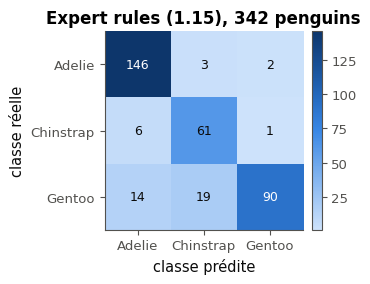

pytest: 16 passed, 214 deselected in 0.97s


In [20]:
C_15 = mylearn.metrics.confusion_matrix(species, expert_pred)
C_15_ordered = mylearn.metrics.confusion_matrix(species, expert_pred, labels=["Gentoo", "Chinstrap", "Adelie"])
print(C_15, C_15_ordered, sep="\n\n")
gentoo_as_chinstrap = int(C_15[2, 1])   # row = truth (Gentoo, 3rd label), column = prediction (Chinstrap, 2nd label)
wb.plot.plot_confusion_matrix(C_15, class_names=["Adelie", "Chinstrap", "Gentoo"], title="Expert rules (1.15), 342 penguins")
plt.show()
run_metrics_tests("test_confusion_matrix_", impl="ref")

In [21]:
wb.record("3.15a", C_15)
wb.record("3.15b", C_15_ordered, mistakes={"ta fonction ignore labels : les lignes et les colonnes doivent suivre l'ordre de labels": C_15})
wb.record("3.15c", gentoo_as_chinstrap, mistakes={"c'est l'inverse, les Chinstrap pris pour des Gentoo : ligne = vérité (Gentoo), colonne = prédiction (Chinstrap)": int(C_15[1, 2])})

WB_ANSWER {"decimals": 0, "element_hashes": ["6267cbb69efecfbd17e89398afde8b96db3f86e8248e541ae30d2c1bbe5ece75", "cafba1bf9db0205e06afa5a2544e6476bffe35d18a11de414b36022003a6dccb", "120c359d9662ee0abac36d99745ba489c27bb5f59673b943d4ea2e2db81c158e", "143dac893a625c685d6c703577890b025f4365db8b0f342d7a4970f89145cf3b", "6655c670e3277079d9da5062b978ce5cfdf4bee32818bbcd27b426f3f1c17dc7", "e5c878e737f28c52ba74a916a00170ea607a0231e0efa9a8fab08dc6a0a3e625", "74c9b4bc941f670e6eeaf8d79bbe7cbdef2847b2027a4ae4b596426b26592617", "66b14421f8297eb733b3d3465b86629302ac79e2a24c5e6bd389f16fabbe1e2d", "856ff4f286d082a5ea8f1fcb8472495381d8a91c1be1bd6b0bf66b0b7ced5fd2"], "hash": "d14d4049abc0f63c00925a9e0f0116c14c5e51aebb1de3f55da2dce2b4fa5955", "id": "3.15a", "integer": true, "kind": "array", "shape": [3, 3]}
📝 Ex 3.15a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["d188398dcb7f0bfd9c169f818a1607cc1f73b322164a0ef79cfb8fef345ff8a8", "bd84a5b73ac646b5af1b0beb69bf9

💡 La diagonale compte les bonnes réponses : 297 sur 342, soit une accuracy de 0,868. Mais la matrice dit **où** sont les erreurs : 33 des 45 erreurs viennent de Gentoo trop légers (4 700 g ou moins), que la règle 2 envoie chez les Chinstrap (bec de plus de 45 mm) ou que la règle 3 laisse chez les Adélie. C'est ce que le ch. 1 avait entrevu en 1.15 ; la matrice le chiffre. La référence est dans `solutions/mylearn_ref/metrics.py` : lis-la **après** avoir réussi les tests.

### Ex 3.16 — accuracy, precision, recall, F-beta et F1 (cas binaire) 🔨 ★★★ ⏱️ 40 min
**Objectif :** écrire accuracy, precision, recall, F-beta et F1 pour deux classes, avec une classe positive au choix.  
**Prérequis :** Ex 3.15 · fiche §3.7.5 à §3.7.11 · **Fil rouge :** synthétique · **mylearn :** `metrics.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/metrics.py`, mêmes règles qu'en 3.15 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `accuracy`, `precision`, `recall`, `fbeta` et `f1` pour le cas **binaire** (`average="binary"`, la valeur par défaut) ; les autres valeurs d'`average` viendront en 3.25 : d'ici là, fais-leur lever une `NotImplementedError`. Relis les docstrings :
- la classe positive est `pos_label`. En binaire, il y a au plus deux labels, cherchés dans `y_true` **et** dans `y_pred` ; s'il y en a deux, `pos_label` doit en faire partie (sinon `ValueError`) ;
- `zero_division` est la valeur renvoyée quand un dénominateur est nul : aucune prédiction positive (precision), aucun positif réel (recall), $TP + FN + FP = 0$ (F-beta) ;
- $F_\beta = \frac{(1 + \beta^2)\,TP}{(1 + \beta^2)\,TP + \beta^2\,FN + FP}$ (fiche §3.7.11) ; `ValueError` si $\beta \le 0$, et `f1` appelle `fbeta` avec $\beta = 1$.

Compte TP, FP et FN dans **une** fonction d'aide que les quatre mesures partagent : moins de code, moins de bugs.

Vérifications, sur le filtre anti-spam (`spam_true`, `spam_pred` ; labels `"spam"` et `"ham"`, classe positive `"spam"`) ; la cellule de vérification appelle tes fonctions :
a) l'accuracy ; b) la precision ; c) le recall ; d) le F1 ; e) le $F_2$ (`fbeta` avec `beta=2`) ;
puis un contrôle : sans `pos_label`, `precision(spam_true, spam_pred)` doit lever une `ValueError`, car le label positif par défaut, 1, n'existe pas ici ; enfin, les tests des cinq fonctions (cas binaire).

Dans tes notes : le $F_2$ est-il plus proche de la precision ou du recall ? Pourquoi ?

In [22]:
mm = mylearn.metrics
values_16 = {"accuracy": mm.accuracy(spam_true, spam_pred),
             "precision": mm.precision(spam_true, spam_pred, pos_label="spam"),
             "recall": mm.recall(spam_true, spam_pred, pos_label="spam"),
             "f1": mm.f1(spam_true, spam_pred, pos_label="spam"),
             "f2": mm.fbeta(spam_true, spam_pred, beta=2, pos_label="spam"),
             "f0.5": mm.fbeta(spam_true, spam_pred, beta=0.5, pos_label="spam")}
print({key: round(value, 3) for key, value in values_16.items()})
print(error_name(mm.precision, spam_true, spam_pred))
run_metrics_tests("(test_accuracy_ or test_precision_ or test_recall_ or test_fbeta_ or test_f1_) and not multiclass and not curve", impl="ref")

{'accuracy': 0.87, 'precision': 0.761, 'recall': 0.689, 'f1': 0.723, 'f2': 0.702, 'f0.5': 0.746}
ValueError


pytest: 81 passed, 149 deselected in 1.92s


In [23]:
n_spam_tp = int(np.sum((spam_true == "spam") & (spam_pred == "spam")))
wb.record("3.16a", values_16["accuracy"], decimals=4, mistakes={"l'accuracy compte les DEUX sortes de bonnes réponses, TP et TN, parmi tous les e-mails": n_spam_tp / len(spam_true)})
wb.record("3.16b", values_16["precision"], decimals=4, mistakes={"c'est le recall : la precision divise TP par le nombre de prédictions positives, TP + FP": values_16["recall"],
                                                                  "c'est la precision de la classe \"ham\" : la classe positive est pos_label": mm.precision(spam_true, spam_pred, pos_label="ham")})
wb.record("3.16c", values_16["recall"], decimals=4, mistakes={"c'est la precision : le recall divise TP par le nombre de positifs réels, TP + FN": values_16["precision"],
                                                               "c'est le recall de la classe \"ham\" : la classe positive est pos_label": mm.recall(spam_true, spam_pred, pos_label="ham")})
wb.record("3.16d", values_16["f1"], decimals=4, mistakes={"c'est la moyenne ordinaire de la precision et du recall : le F1 est leur moyenne HARMONIQUE": (values_16["precision"] + values_16["recall"]) / 2})
wb.record("3.16e", values_16["f2"], decimals=4, mistakes={"c'est le F0,5 : dans la formule, β² multiplie FN (β = 2 favorise le recall)": values_16["f0.5"],
                                                           "c'est le F1 : ta fonction utilise-t-elle bien beta ?": values_16["f1"]})

WB_ANSWER {"decimals": 4, "hash": "c3944d83a8b29b4388def9c01f930a5a442aaf381a6eec671616a049531666f8", "hash_coarse": "98756305b090ecc0f1d37b07c8d315eaecf803042904b764c9a5bf865d17db59", "id": "3.16a", "kind": "float", "magnitude": -1, "mistakes": {"9bd89f3de33e11798b82523eb36a7c10ad97d28c3e1c3e92007b7c6317a3e432": "l'accuracy compte les DEUX sortes de bonnes réponses, TP et TN, parmi tous les e-mails"}, "sign": 1}
📝 Ex 3.16a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "edb2627cca070ebecc305205fb391df7e0bb2945c5a632e7e8a5b56a7ba3b7fb", "hash_coarse": "1e55f1b1e6b4a08119ce304f6cc27f55ae9518e33304097d1d5d5abc306f5c03", "id": "3.16b", "kind": "float", "magnitude": -1, "mistakes": {"1c46ecf86da0d656fd77bf1fb78ce253e45cf9f3bad722a545868d1ab0ada290": "c'est la precision de la classe \"ham\" : la classe positive est pos_label", "2bd3643a0102ff8d09bf69c9e4c060ebcee0c23180be79221e86778c0f0e6703": "c'est le recall : la precision divise TP par le nombre de prédic

💡 Ce filtre a une bonne accuracy (0,870), une precision correcte (0,761) et un recall plus faible (0,689) : il laisse passer près d'un spam sur trois. Le $F_2$ (0,702) est plus proche du recall, le plus faible des deux, parce que $\beta = 2$ donne 4 fois plus de poids aux faux négatifs ; le $F_{0,5}$ (0,746) est plus proche de la precision. Toutes ces mesures sont des fractions de la même matrice : avec une seule fonction d'aide qui compte TP, FP et FN, les cinq fonctions tiennent en quelques lignes.

### Ex 3.17 — La matrice à l'envers 🐛 ★★ ⏱️ 15 min
**Objectif :** diagnostiquer une matrice de confusion lue dans le mauvais sens, puis écrire une version juste quelles que soient les labels.  
**Prérequis :** Ex 3.16 · fiche §3.7.2 (🕰️ conventions de scikit-learn), §3.7.3 · **Fil rouge :** synthétique · **Parcours :** C

Un laboratoire évalue un test de dépistage rapide sur 2 000 personnes : `test_truth` contient la vérité (`"malade"` ou `"sain"`) et `test_result` le résultat du test. Un collègue a écrit `screening_report`, qui renvoie la sensibilité (le recall des malades) et la precision (la part de malades parmi les tests positifs). Son code tourne, ses chiffres semblent plausibles… et ils sont faux.

a) `true_sensitivity_17` : la vraie sensibilité du test, calculée avec **tes** fonctions de `mylearn.metrics` (3 décimales) ;
b) `true_precision_17` : sa vraie precision, avec tes fonctions aussi (3 décimales) ;
c) `top_left_17` : dans `skm.confusion_matrix(test_truth, test_result)`, quelle case se trouve en haut à gauche : `"TP"`, `"FN"`, `"FP"` ou `"TN"` (la classe positive étant `"malade"`) ? C'est la clé du bug.

Puis corrige : écris `screening_report_fixed(y_true, y_pred, positive)`, qui renvoie `{"sensitivity": ..., "precision": ...}`, juste quels que soient les labels, la classe positive étant `positive`. La vérification l'essaie avec quatre jeux de labels. Dans tes notes : quelles mesures le collègue a-t-il calculées en réalité ? Pourquoi son code marche-t-il avec des labels 0 et 1, et pas ici ? Comment l'aurais-tu repéré ?

In [24]:
rng_17 = np.random.default_rng(17)
sick_17 = rng_17.random(2000) < 0.10
u_17 = rng_17.random(2000)
test_truth = np.where(sick_17, "malade", "sain")                                          # the truth
test_result = np.where(np.where(sick_17, u_17 < 0.85, u_17 < 0.05), "malade", "sain")   # the rapid test


def screening_report(y_true, y_pred):
    """Sensitivity and precision of a screening test (the colleague's version)."""
    tn, fp, fn, tp = skm.confusion_matrix(y_true, y_pred).ravel()
    return {"sensitivity": tp / (tp + fn), "precision": tp / (tp + fp)}


print("the colleague's report:", {key: round(float(value), 3) for key, value in screening_report(test_truth, test_result).items()})

the colleague's report: {'sensitivity': 0.947, 'precision': 0.985}


In [25]:
true_sensitivity_17 = mylearn.metrics.recall(test_truth, test_result, pos_label="malade")
true_precision_17 = mylearn.metrics.precision(test_truth, test_result, pos_label="malade")
print(skm.confusion_matrix(test_truth, test_result))    # labels sorted: "malade" < "sain", so row 0 = the sick
top_left_17 = "TP"


def screening_report_fixed(y_true, y_pred, positive):
    """{"sensitivity": ..., "precision": ...} for any labels; `positive` is the positive class."""
    truth = np.asarray(y_true) == positive
    alarm = np.asarray(y_pred) == positive
    tp, fn, fp = np.sum(truth & alarm), np.sum(truth & ~alarm), np.sum(~truth & alarm)
    return {"sensitivity": float(tp / (tp + fn)), "precision": float(tp / (tp + fp))}


print(true_sensitivity_17, true_precision_17, screening_report_fixed(test_truth, test_result, "malade"))

[[ 153   26]
 [  97 1724]]
0.8547486033519553 0.612 {'sensitivity': 0.8547486033519553, 'precision': 0.612}


In [26]:
wrong_17 = screening_report(test_truth, test_result)
wb.record("3.17a", true_sensitivity_17, decimals=3, mistakes={"c'est la sensibilité annoncée par le collègue : recalcule-la avec tes fonctions (le recall, classe positive \"malade\")": float(wrong_17["sensitivity"]),
                                                              "c'est la precision : la sensibilité est le RECALL des malades": true_precision_17})
wb.record("3.17b", true_precision_17, decimals=3, mistakes={"c'est la precision annoncée par le collègue : recalcule-la avec tes fonctions (classe positive \"malade\")": float(wrong_17["precision"]),
                                                            "c'est la sensibilité (le recall) : la precision divise par les tests POSITIFS": true_sensitivity_17})
wb.record("3.17c", top_left_17, mistakes={"c'est vrai pour des labels 0 et 1, rangés 0 puis 1 ; ici, scikit-learn trie des mots : lequel vient en premier, \"malade\" ou \"sain\" ?": "TN",
                                           "la case en haut à gauche est sur la diagonale : une bonne réponse, pas un faux négatif": "FN",
                                           "la case en haut à gauche est sur la diagonale : une bonne réponse, pas un faux positif": "FP"})

WB_ANSWER {"decimals": 3, "hash": "43c92accb99d083b7808ddc6970b1039da3310a08641fcd553022ad50138659f", "hash_coarse": "5b84db43dae1ecb7c0639cf5cf9f1739e94f789cb72c7b36bd77b2a9ba4ac86d", "id": "3.17a", "kind": "float", "magnitude": -1, "mistakes": {"b81e28cfc4da05e196ea81936a0f821bd83770404940e9c0c0c5c7b0ae1e3499": "c'est la precision : la sensibilité est le RECALL des malades", "d3a3aef06adfe451ba661202ab99ce1a657a9f080320f34663a76c4ea47890a3": "c'est la sensibilité annoncée par le collègue : recalcule-la avec tes fonctions (le recall, classe positive \"malade\")"}, "sign": 1}
📝 Ex 3.17a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "13e141062c28b3a15ac4fadb00ab6a31dae1e1a387388ee172373de64e565fcc", "hash_coarse": "947d5169a590ac399e32792443b5435fe4b684532741165c5993a1c7229c238d", "id": "3.17b", "kind": "float", "magnitude": -1, "mistakes": {"130631a87ded01368d305c526bf56989a0e9425b6bce1a9874908f21a713e967": "c'est la sensibilité (le recall) : la precis

💡 `confusion_matrix` range les labels dans l'ordre **trié** : `"malade" < "sain"`, donc la ligne 0 est celle des malades et la matrice vaut `[[TP, FN], [FP, TN]]`. Le `.ravel()` du collègue range TP dans sa variable `tn`, FN dans `fp`, FP dans `fn` et TN dans `tp` : sa « sensibilité » est en réalité la spécificité, $\frac{TN}{TN + FP}$, et sa « precision » la NPV, $\frac{TN}{TN + FN}$. Avec des labels 0/1 (ou `"no"`/`"yes"`), le positif est trié en second et le code tombe juste… par chance. Corrections sûres : `labels=[negative, positive]` dans `confusion_matrix`, ou des masques booléens comme ici. Pour le repérer : tester la fonction sur un petit exemple calculé à la main, avec les labels réels du projet.

### Ex 3.18 — Tout positif, un seul positif : prédire les scores 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir l'accuracy, le F1 et la balanced accuracy de deux classifieurs extrêmes, et voir que ces mesures ne les classent pas dans le même ordre.  
**Prérequis :** Ex 3.16 · fiche §3.7.9 (balanced accuracy), §3.7.10 · **Fil rouge :** synthétique · **Parcours :** C

Un jeu de test de 40 échantillons contient 8 positifs. Deux classifieurs paresseux :
- le classifieur 1 répond « positif » pour **tous** les échantillons ;
- le classifieur 2 ne répond « positif » que pour **un seul** échantillon, le plus évident, qui est bien un positif ; « négatif » pour tous les autres.

La fiche (§3.7.10) donne déjà leur precision et leur recall. **Sans rien exécuter**, prévois :
a) `prediction_3_18a` : l'accuracy du classifieur 1 (2 décimales) ;
b) `prediction_3_18b` : son F1 (3 décimales) ;
c) `prediction_3_18c` : l'accuracy du classifieur 2 (3 décimales) ;
d) `prediction_3_18d` : son F1 (3 décimales) ;
e) `prediction_3_18e` : lequel a la meilleure balanced accuracy (fiche §3.7.9) : `1` ou `2` ?

Écris ton hypothèse (cellule 📝), puis tes cinq prédictions ; la vérification ne regarde que tes prédictions. Ensuite seulement, exécute l'**Expérience**.

In [27]:
prediction_3_18a, prediction_3_18b = 8 / 40, 2 * 8 / (2 * 8 + 32 + 0)        # TP = 8, FP = 32, FN = 0
prediction_3_18c, prediction_3_18d = 33 / 40, 2 * 1 / (2 * 1 + 0 + 7)       # TP = 1, FP = 0, FN = 7, TN = 32
prediction_3_18e = 2                                                        # (1/8 + 1) / 2 against (1 + 0) / 2

In [28]:
wb.record("3.18a", prediction_3_18a, decimals=2, mistakes={"c'est son recall : l'accuracy compte les bonnes réponses parmi les 40 échantillons": 1.0,
                                                              "c'est la part des négatifs : le classifieur 1 se trompe justement sur eux": 0.8})
wb.record("3.18b", prediction_3_18b, decimals=3, mistakes={"c'est la moyenne ordinaire de la precision et du recall : le F1 est leur moyenne HARMONIQUE": 0.6})
wb.record("3.18c", prediction_3_18c, decimals=3, mistakes={"c'est sa precision : l'accuracy compte TOUTES les bonnes réponses, négatifs compris": 1.0,
                                                            "l'accuracy compte TOUTES les bonnes réponses, négatifs compris": 1 / 40})
wb.record("3.18d", prediction_3_18d, decimals=3, mistakes={"c'est la moyenne ordinaire de la precision et du recall : le F1 est leur moyenne HARMONIQUE": 0.5625,
                                                            "c'est la moyenne ordinaire (arrondie) de la precision et du recall : le F1 est leur moyenne HARMONIQUE": 0.563,
                                                            "c'est son recall : le F1 combine precision ET recall": 0.125})
wb.record("3.18e", prediction_3_18e, mistakes={"la balanced accuracy fait la moyenne du recall ET de la spécificité : que vaut la spécificité du classifieur 1 ?": 1})

WB_ANSWER {"decimals": 2, "hash": "88a29a450c3dc0cb00922ccdc4e6637724ec778b9a7721ba0930dd53d3f002ab", "hash_coarse": "3c5308c95e6cb7bee2335d7caa0dd93a4a4d80fc457bc43a33502e337c8558d8", "id": "3.18a", "kind": "float", "magnitude": -1, "mistakes": {"6366731e622551ebbb64e4be99afc9fd2c78b672e59cec37259574996c2d56ed": "c'est la part des négatifs : le classifieur 1 se trompe justement sur eux", "a3300f6c0649d3e16baf9e8f326256cbb8c20778513b7343babb6ae19106590b": "c'est son recall : l'accuracy compte les bonnes réponses parmi les 40 échantillons"}, "sign": 1}
📝 Ex 3.18a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "4e888b8a739aa77728145dc8a15f17eccc357dcb0ce68cbe4b055708528f576d", "hash_coarse": "2a0fe0bce66ee6ad0adf9e535a4263fea56521005dc9cd098f8d3891359a63eb", "id": "3.18b", "kind": "float", "magnitude": -1, "mistakes": {"04afed460dd50f769ec4f7528dde769306ce35c7fe84a928ee063f187e25d93a": "c'est la moyenne ordinaire de la precision et du recall : le F1 est l

**Expérience** : exécute la cellule et compare avec tes prédictions.

In [29]:
if any(answer is ... or answer is None for answer in [prediction_3_18a, prediction_3_18b, prediction_3_18c, prediction_3_18d, prediction_3_18e]):
    print("⏳ Ex 3.18 : écris d'abord tes cinq prédictions, puis relance cette cellule.")
else:
    y_18 = np.array([1] * 8 + [0] * 32)          # 8 positives, then 32 negatives
    all_positive = np.ones(40, dtype=int)          # classifier 1
    one_positive = np.zeros(40, dtype=int)         # classifier 2: only the most obvious case, a real positive
    one_positive[0] = 1
    for name, pred in [("1: all positive", all_positive), ("2: one positive", one_positive)]:
        print(f"{name:<16} accuracy {skm.accuracy_score(y_18, pred):.3f} · F1 {skm.f1_score(y_18, pred):.3f} · "
              f"balanced accuracy {skm.balanced_accuracy_score(y_18, pred):.4f} · "
              f"precision {skm.precision_score(y_18, pred):.3f} · recall {skm.recall_score(y_18, pred):.3f}")

1: all positive  accuracy 0.200 · F1 0.333 · balanced accuracy 0.5000 · precision 0.200 · recall 1.000
2: one positive  accuracy 0.825 · F1 0.222 · balanced accuracy 0.5625 · precision 1.000 · recall 0.125


💡 L'accuracy préfère largement le classifieur 2 (0,825 contre 0,2), le F1 préfère le 1 (0,333 contre 0,222), et la balanced accuracy les trouve presque aussi mauvais l'un que l'autre (0,5 et 0,5625, près de 0,5, le score du hasard). Aucun n'est utile : le 1 ne distingue rien, le 2 rate 7 positifs sur 8. Leçon : une mesure seule se laisse berner par un classifieur dégénéré, et deux mesures peuvent classer deux modèles en sens inverse. Compare toujours à une référence triviale (la classe majoritaire, tout positif) et regarde la matrice.

### Ex 3.19 — Le tableau de bord complet : classification_rates 🔨 ★★ ⏱️ 20 min
**Objectif :** calculer d'un coup les 13 mesures d'une matrice binaire, avec une seule règle pour les divisions par zéro.  
**Prérequis :** Ex 3.16, Ex 3.5 · fiche §3.7.9 (tableau et 🕰️) · **Fil rouge :** synthétique · **mylearn :** `metrics.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/metrics.py`, mêmes règles qu'en 3.15 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `classification_rates(y_true, y_pred, pos_label=1, zero_division=0.0)`, qui renvoie un dictionnaire des 13 mesures du tableau de la fiche (§3.7.9), **dans l'ordre de la docstring** (un dictionnaire Python garde l'ordre d'insertion). Compte TP, FN, FP et TN une seule fois, puis écris une petite fonction d'aide `ratio(num, den)` qui renvoie `zero_division` quand `den` vaut 0 : **tous** les rapports passent par elle, ceux du MCC et de la balanced accuracy compris (scikit-learn a pour ces deux-là ses propres conventions ; les tests suivent la docstring). Mêmes contrôles des labels qu'en 3.16 ; chaque valeur est un `float`.

Vérifications, sur le filtre anti-spam de 3.16 (classe positive `"spam"`) :
a) `[specificity, npv, balanced_accuracy, mcc]`, calculés par ta fonction (la cellule de vérification l'appelle) ;
b) `swap_19` : si l'on prend `"ham"` comme classe positive, la precision devient l'une des autres mesures du tableau calculé avec `"spam"` : laquelle ? (sa clé, une chaîne) ;
puis l'ordre des clés, et les tests de `classification_rates`.

In [30]:
rates_19 = mylearn.metrics.classification_rates(spam_true, spam_pred, pos_label="spam")
print({key: round(value, 3) for key, value in rates_19.items()})
rates_ham = mylearn.metrics.classification_rates(spam_true, spam_pred, pos_label="ham")
print("precision with 'ham' as the positive class:", round(rates_ham["precision"], 3))
swap_19 = "npv"
run_metrics_tests("test_classification_rates_", impl="ref")

{'accuracy': 0.87, 'balanced_accuracy': 0.809, 'precision': 0.761, 'recall': 0.689, 'specificity': 0.929, 'npv': 0.901, 'fpr': 0.071, 'fnr': 0.311, 'fdr': 0.239, 'false_omission_rate': 0.099, 'prevalence': 0.247, 'f1': 0.723, 'mcc': 0.64}
precision with 'ham' as the positive class: 0.901


pytest: 14 passed, 216 deselected in 2.56s


In [31]:
r19 = rates_19
wb.record("3.19a", [r19["specificity"], r19["npv"], r19["balanced_accuracy"], r19["mcc"]], decimals=4,
          mistakes={"la spécificité et la NPV sont échangées : la spécificité divise TN par les négatifs RÉELS (TN + FP), la NPV par les prédictions négatives (TN + FN)": [r19["npv"], r19["specificity"], r19["balanced_accuracy"], r19["mcc"]],
                    "la balanced accuracy est la moyenne du recall et de la SPÉCIFICITÉ (pas de la precision)": [r19["specificity"], r19["npv"], (r19["precision"] + r19["recall"]) / 2, r19["mcc"]]})
wb.record("3.19b", swap_19, mistakes={"c'est ce que devient le RECALL de \"ham\", pas sa precision : une precision divise par des PRÉDICTIONS, pas par des cas réels": "specificity",
                                      "une precision divise par des PRÉDICTIONS : écris la precision de \"ham\" avec les quatre cases de la matrice \"spam\"": "recall"})

WB_ANSWER {"decimals": 4, "element_coarse": [["60774b417be127c65f12853ab43ac569328be4631c07b4bc2dd461a4c0852cbe"], ["555c9d42f1592926f3e61e70bdbde6ebc63557a9c15d2dd826ce30abe3479811"], ["5eeec60e1abf315eccaaf68a95cd994a9e64ab1e256f47a13606856d7cacec2b"], ["c2fd26ebc22b9a3a270d844a98190e33aeb1e04106892800be95f8343c794650"]], "element_hashes": ["f464af9fc755b81846adc9ba231f22ef23235ee63f1e05d3fd0ecf6c18238005", "7fe7d2823e7c380306ec44329ec0adb0afaeb9343f73131313e8c974b7642e2d", "ab255b1069c6dcda3a675cb89318a7fc21ae48efe605ca99aeca074bcb1e1c4e", "4a2d7576daadc37c4b096e1ff96593471d1629ae78f8decbbf741e568adb4847"], "hash": "fee3cb5ec8d3dfcd183a500da74bb767db2bd9c1111fc02e66d3e11ca7300924", "id": "3.19a", "kind": "array", "mistakes": {"2ff1ec2a8d470e1110788604e4248f2ef4efbf1fbd41abf9a33a68b7d6529bda": "la balanced accuracy est la moyenne du recall et de la SPÉCIFICITÉ (pas de la precision)", "cfd8c20157549970370546b501ae56501c96dd8bf77951dc303b6bd6cd24e2fb": "la spécificité et la NPV sont éc

💡 Changer de classe positive échange les rôles : la precision de « ham » est la NPV de « spam », son recall est la spécificité de « spam ». Le tableau entier se déduit des quatre cases ; `classification_rates` le calcule une fois pour toutes. La règle unique `zero_division` rend la fonction prévisible dans les cas dégénérés (une classe jamais prédite, un jeu sans positif), là où scikit-learn a des conventions qui varient d'une fonction à l'autre.

## Partie C · Seuil, prévalence et outils de scikit-learn

Fiche §3.7.4, §3.7.10 et §3.8. Un classifieur donne souvent un **score** ; le seuil qui en fait une décision se choisit selon le coût des erreurs (3.20). La precision dépend de la prévalence : tu le vérifies par la simulation (3.21). Enfin, tu contrôles tes résultats avec les outils de scikit-learn et tu apprends à lire leur documentation (3.22, 3.23).

### Ex 3.20 — Un seuil sur la nageoire : precision et recall en balance 🔬 ★★ ⏱️ 25 min
**Objectif :** balayer les seuils d'un score, puis choisir un seuil selon le F1 ou selon le coût des erreurs.  
**Prérequis :** Ex 3.16 · fiche §3.7.4, §3.7.10 (🧮 score et seuil), §3.7.11 · **Fil rouge :** Penguins · **Parcours :** R, M, C

Pas encore de modèle entraîné (ce sera au ch. 7) : le **score** est ici une simple mesure, la longueur de la nageoire (`flipper`, en mm, des nombres entiers). La classe positive est « Gentoo » (`is_gentoo` : 1 pour un Gentoo, 0 sinon), contre les deux autres espèces. Au seuil $t$, on prédit « Gentoo » quand `flipper >= t` (supérieur **ou égal**).

Écris d'abord `sweep_20(thresholds)`, qui renvoie un DataFrame avec une ligne par seuil et les colonnes `threshold`, `precision`, `recall`, `f1`, `fn` et `fp`, calculées avec tes fonctions de `mylearn.metrics` (les prédictions en 0/1 : `(flipper >= t).astype(int)`). La vérification trace precision, recall et F1 en fonction du seuil, avec ton tableau `sweep_20(np.arange(190, 231))`. Puis :

a) `pr_205` : `[precision, recall]` au seuil $t = 205$ mm (3 décimales) ;
b) `best_f1_t` : parmi les seuils entiers de 190 à 230 mm, celui qui maximise le F1 ;
c) `best_cost_t` : un Gentoo manqué (FN) coûte 10, un faux Gentoo (FP) coûte 1 ; parmi les mêmes seuils, celui qui minimise le coût total $10 \times FN + 1 \times FP$.

Lis b et c dans ton tableau (`idxmax`, `idxmin`, 0A). Dans tes notes : pourquoi les seuils de b et c diffèrent-ils ? Lequel choisirais-tu pour un recensement où rater un Gentoo coûte cher ?

 threshold  precision  recall    f1  fn  fp  cost
       200      0.809   1.000 0.895   0  29    29
       201      0.831   1.000 0.908   0  25    25
       202      0.866   1.000 0.928   0  19    19
       203      0.891   1.000 0.943   0  15    15
       204      0.917   0.992 0.953   1  11    21
       205      0.917   0.992 0.953   1  11    21
       206      0.938   0.992 0.964   1   8    18
       207      0.946   0.992 0.968   1   7    17
       208      0.953   0.984 0.968   2   6    26
       209      0.958   0.927 0.942   9   5    95
       210      0.956   0.886 0.920  14   5   145
       211      0.990   0.805 0.888  24   1   241
       212      0.990   0.789 0.878  26   1   261
       213      1.000   0.740 0.850  32   0   320
[np.float64(0.9172932330827067), np.float64(0.991869918699187)] 207 203


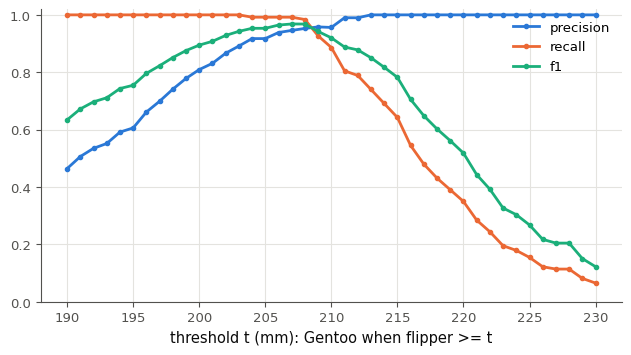

In [32]:
def sweep_20(thresholds):
    """One row per threshold t (Gentoo when flipper >= t): threshold, precision, recall, f1, fn, fp."""
    rows = []
    for t in thresholds:
        pred = (flipper >= t).astype(int)
        rows.append({"threshold": int(t),
                     "precision": mylearn.metrics.precision(is_gentoo, pred),
                     "recall": mylearn.metrics.recall(is_gentoo, pred),
                     "f1": mylearn.metrics.f1(is_gentoo, pred),
                     "fn": int(np.sum((is_gentoo == 1) & (pred == 0))),
                     "fp": int(np.sum((is_gentoo == 0) & (pred == 1)))})
    return pd.DataFrame(rows)


table_20 = sweep_20(np.arange(190, 231))
row_205 = table_20.set_index("threshold").loc[205]
pr_205 = [row_205["precision"], row_205["recall"]]
best_f1_t = int(table_20.loc[table_20["f1"].idxmax(), "threshold"])
table_20["cost"] = 10 * table_20["fn"] + table_20["fp"]
best_cost_t = int(table_20.loc[table_20["cost"].idxmin(), "threshold"])
print(table_20[(table_20["threshold"] >= 200) & (table_20["threshold"] <= 213)].round(3).to_string(index=False))
print(pr_205, best_f1_t, best_cost_t)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for column in ["precision", "recall", "f1"]:
    ax.plot(table_20["threshold"], table_20[column], marker=".", label=column)
ax.set_xlabel("threshold t (mm): Gentoo when flipper >= t")
ax.set_ylim(0, 1.02)
ax.legend()
plt.show()

In [33]:
row_206 = table_20.set_index("threshold").loc[206]  # "flipper > 205" is "flipper >= 206" for whole numbers
wb.record("3.20a", pr_205, decimals=3, mistakes={"c'est [recall, precision] : l'ordre demandé est [precision, recall]": pr_205[::-1],
                                                  "au seuil t, on prédit Gentoo quand flipper >= t (supérieur OU ÉGAL), pas >": [row_206["precision"], row_206["recall"]]})
IDX_20 = "c'est le numéro de la ligne, pas le seuil : idxmax et idxmin renvoient le label de la ligne ; lis la colonne threshold de cette ligne"
wb.record("3.20b", best_f1_t, mistakes={"on prédit Gentoo quand flipper >= t (supérieur OU ÉGAL), pas > : ton seuil est décalé d'un millimètre": best_f1_t - 1,
                                         "le F1 de ce seuil est presque le meilleur, mais pas le meilleur : compare les F1 sans les arrondir": best_f1_t + 1,
                                         IDX_20: best_f1_t - 190})
wb.record("3.20c", best_cost_t, mistakes={"on prédit Gentoo quand flipper >= t (supérieur OU ÉGAL), pas > : ton seuil est décalé d'un millimètre": best_cost_t - 1,
                                           "c'est le seuil du meilleur F1 : ici, on minimise le coût 10 × FN + FP": best_f1_t,
                                           IDX_20: best_cost_t - 190,
                                           "un FN coûte 10 et un FP coûte 1, pas l'inverse": int(table_20.loc[(table_20["fn"] + 10 * table_20["fp"]).idxmin(), "threshold"])})

WB_ANSWER {"decimals": 3, "element_coarse": [["48b58fddaa7d8e3fcbd65fc6f72933496beeaa29cdef8a50b7a9d5203a8ad849"], ["b145f1baf2337c16ebad128b949e2025e0c2620160a86629ad628b7d2274b8a2"]], "element_hashes": ["3a1c7ae715cbe4605997c54d01793df0b52cf6b878eceea7a1a901f1026ce350", "65a05a0b9f2239b43c9940a062dd9f618b2ccaeba9d699538e41791fbd95a4ce"], "hash": "4cc67b7f12bf0ca8871cb2c8e6e67d43ca28ad252a39ed41c1dc89b40d03082a", "id": "3.20a", "kind": "array", "mistakes": {"6e923d85724e6ff257f042c0bebdc5d26cb32c09a80f48cee232654cddce1e45": "au seuil t, on prédit Gentoo quand flipper >= t (supérieur OU ÉGAL), pas >", "a4b2ec9bee61f939c07050a859963d43ed6eca4a5946cfa66fefb5721e23737b": "c'est [recall, precision] : l'ordre demandé est [precision, recall]"}, "shape": [2]}
📝 Ex 3.20a : réponse enregistrée (array, 3 décimale(s)).
WB_ANSWER {"hash": "ed0113d4796ef18c01796293e9aed1935f0233cec588f5780026bc5960035adb", "id": "3.20b", "kind": "int", "magnitude": 2, "mistakes": {"0891cda2b70db9cf2a62ece2128e33635

💡 Au seuil 205 mm, un seul Gentoo est manqué, mais 11 manchots d'autres espèces sont pris pour des Gentoo. En montant le seuil, la precision monte et le recall baisse ; le F1 est maximal à 207 mm, où il reste un FN et 7 FP. Si rater un Gentoo coûte 10 fois plus cher qu'une fausse alerte, le meilleur seuil descend à 203 mm : aucun Gentoo manqué, 15 fausses alertes. Le F1 suppose implicitement qu'un FN et un FP ont à peu près le même poids ; dès que les coûts sont connus, on minimise le coût. Attention : choisir le seuil sur les données où l'on mesure le résultat est optimiste. Il faudrait le choisir sur un jeu de validation (ch. 8) : c'est l'objet du défi 3.29.

### Ex 3.21 — Simuler le dépistage : la prévalence fait la precision 🔬 ★★ ⏱️ 30 min
**Objectif :** vérifier par la simulation que la precision d'un test dépend de la prévalence, et trouver la prévalence à partir de laquelle un positif est plus souvent malade que sain.  
**Prérequis :** Ex 3.7, Ex 3.19 · ch. 2 (tirages de Bernoulli, graine) · fiche §3.8 · **Fil rouge :** synthétique · **Parcours :** M, C

Le test du livre (§3.8) a une sensibilité de 0,99 et une spécificité de 0,98 ; 1 % de la population est malade. Tu as calculé ses mesures sur papier (3.7, 2ᵉ partie) ; ici, tu mesures sa precision sur une population simulée.

Écris `simulate_screening(n, prevalence, sensitivity, specificity, rng)`, qui renvoie deux tableaux de booléens `(sick, positive)` de longueur $n$, tirés **exactement** ainsi (pour que tout le monde obtienne les mêmes nombres) :
1. `sick = rng.random(n) < prevalence` ;
2. puis `u = rng.random(n)` : une personne est positive si `u < sensitivity` quand elle est malade, si `u < 1 - specificity` quand elle est saine (`np.where`).

a) `precision_21` : la precision mesurée sur $n = 100\,000$ personnes, avec `rng = np.random.default_rng(21)` (4 décimales) ; par exemple avec ta fonction `classification_rates` de 3.19 (convertis d'abord les booléens en 0/1 avec `.astype(int)`), ou directement en comptant ;
b) écris `theoretical_precision(prevalence, sensitivity, specificity)`, la precision attendue (fréquences naturelles, fiche §3.8), puis `theory_21` : ses valeurs pour une prévalence de 0,1 % et de 10 % (liste, 3 décimales) ;
c) `half_21` : la prévalence pour laquelle la precision vaut exactement 0,5 (4 décimales) : un positif a alors autant de chances d'être malade que sain. Résous l'équation à la main, ou cherche-la sur une grille de prévalences (un pas d'au plus 0,000 01, et la prévalence dont la precision est la plus proche de 0,5) ;
d) `double_21` : juste après le premier test (avec le même générateur, sans le recréer), fais passer un **second** test indépendant, de mêmes caractéristiques, à toute la population : `u2 = rng.random(n)`, puis la même règle qu'au point 2. Quelle est la precision parmi les personnes positives **aux deux** tests (3 décimales) ?

La vérification trace la precision théorique en fonction de la prévalence, avec ton point simulé. Dans tes notes : pourquoi un second test change-t-il autant la precision ? (Le ch. 4, règle de Bayes, y reviendra.)

1003 sick, 3063 positive · precision 0.3255 (theory 0.3333)
[0.047210300429184504, 0.846153846153846] 0.019801980198019802 0.4999999999999997 · two tests: 1026 people, precision 0.9591


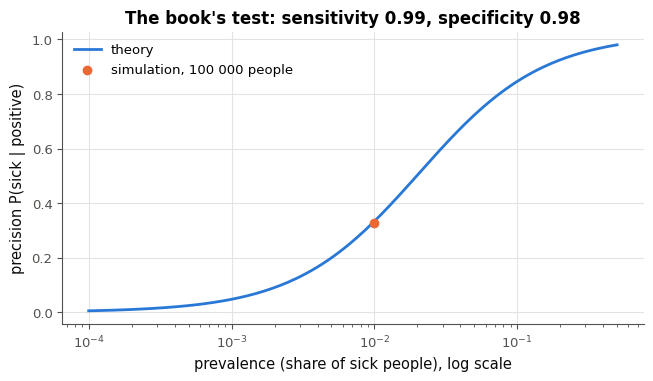

In [34]:
def simulate_screening(n, prevalence, sensitivity, specificity, rng):
    """(sick, positive): two boolean arrays of length n, drawn exactly as in the statement."""
    sick = rng.random(n) < prevalence
    u = rng.random(n)
    positive = np.where(sick, u < sensitivity, u < 1 - specificity)
    return sick, positive


def theoretical_precision(prevalence, sensitivity, specificity):
    """Expected precision P(sick | positive) of the test (natural frequencies)."""
    true_positives = sensitivity * prevalence                 # share of the population: sick and positive
    false_positives = (1 - specificity) * (1 - prevalence)    # healthy and positive
    return true_positives / (true_positives + false_positives)


rng = np.random.default_rng(21)
sick_21, positive_21 = simulate_screening(100_000, 0.01, 0.99, 0.98, rng)
rates_21 = mylearn.metrics.classification_rates(sick_21.astype(int), positive_21.astype(int))
precision_21 = rates_21["precision"]
theory_21 = [theoretical_precision(0.001, 0.99, 0.98), theoretical_precision(0.1, 0.99, 0.98)]
half_21 = 0.02 / (0.99 + 0.02)            # 0.99 p = 0.02 (1 - p): as many true as false positives
u2 = rng.random(100_000)                  # the second test, with the same generator
positive_2 = np.where(sick_21, u2 < 0.99, u2 < 0.02)
both_21 = positive_21 & positive_2
double_21 = np.sum(sick_21 & both_21) / np.sum(both_21)
print(f"{sick_21.sum()} sick, {positive_21.sum()} positive · precision {precision_21:.4f} (theory {theoretical_precision(0.01, 0.99, 0.98):.4f})")
print(theory_21, half_21, theoretical_precision(half_21, 0.99, 0.98), f"· two tests: {np.sum(both_21)} people, precision {double_21:.4f}")
prevalences_21 = np.logspace(-4, np.log10(0.5), 200)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(prevalences_21, [theoretical_precision(p, 0.99, 0.98) for p in prevalences_21], label="theory")
ax.scatter([0.01], [np.sum(sick_21 & positive_21) / np.sum(positive_21)], color="C1", zorder=3,
           label="simulation, 100 000 people")
ax.set_xscale("log")
ax.set_xlabel("prevalence (share of sick people), log scale")
ax.set_ylabel("precision P(sick | positive)")
ax.set_title("The book's test: sensitivity 0.99, specificity 0.98")
ax.legend()
plt.show()

In [35]:
sick_x = np.random.default_rng(21).random(100_000) < 0.01           # classic slip: the generator re-created for u
u_x = np.random.default_rng(21).random(100_000)
positive_x = np.where(sick_x, u_x < 0.99, u_x < 0.02)
u2_x = np.random.default_rng(21).random(100_000)                     # classic slip: re-created for the second test
both_x = positive_21 & np.where(sick_21, u2_x < 0.99, u2_x < 0.02)
wb.record("3.21a", precision_21, decimals=4, mistakes={"tire u avec le MÊME générateur, juste après les malades, sans le recréer : recréé, il redonne les mêmes nombres, et le test « sait » qui est malade": np.sum(sick_x & positive_x) / np.sum(positive_x),
                                                          "c'est la precision THÉORIQUE : on demande celle que tu mesures sur ta population simulée": theoretical_precision(0.01, 0.99, 0.98),
                                                          "c'est la part des positifs dans toute la population : la precision ne regarde que les positifs, et compte ceux qui sont malades": positive_21.mean()})
wb.record("3.21b", theory_21, decimals=3, mistakes={"les faux positifs viennent des personnes SAINES : multiplie 1 − spécificité par 1 − prévalence": [0.99 * p / (0.99 * p + 0.02) for p in (0.001, 0.1)]})
wb.record("3.21c", half_21, decimals=4, mistakes={"c'est 1 − spécificité : la precision vaut 0,5 quand les vrais positifs sont aussi nombreux que les faux ; écris les deux en fonction de la prévalence p": 0.02,
                                                  "les faux positifs viennent des personnes SAINES, une part 1 − p de la population, pas de toute la population": 0.02 / 0.99})
wb.record("3.21d", double_21, decimals=3, mistakes={"c'est la valeur THÉORIQUE pour deux tests indépendants : on demande la precision mesurée sur ta simulation": theoretical_precision(theoretical_precision(0.01, 0.99, 0.98), 0.99, 0.98),
                                                     "c'est la precision d'UN seul test : garde les personnes positives aux deux tests, et tire le second test à la suite du premier, avec le même générateur (recréé, il rejouerait le premier test)": precision_21,
                                                     "tu as recréé le générateur pour le second test : il rejoue des nombres déjà utilisés, et les deux tests ne sont plus indépendants ; tire u2 à la suite, avec le même générateur": np.sum(sick_21 & both_x) / np.sum(both_x)})

WB_ANSWER {"decimals": 4, "hash": "9f8dc7cbdd82d8e4ce2e29e136bc2bbfdc0da606078fac7bb266506e5879c62f", "hash_coarse": "977cd41222eaa13b48b9ed9208f48853766311477e8ccb1ed20f9dae8bd9aa8c", "id": "3.21a", "kind": "float", "magnitude": -1, "mistakes": {"37a87d72096c6602b6d4f1e2bc14866b5fceeba0bcd163e0f576a9b8840169dc": "c'est la part des positifs dans toute la population : la precision ne regarde que les positifs, et compte ceux qui sont malades", "b0a27bd506857917112743a4751c94645ea6a6875fdad2516c41cff113987965": "tire u avec le MÊME générateur, juste après les malades, sans le recréer : recréé, il redonne les mêmes nombres, et le test « sait » qui est malade", "fa47d682e7b322ec6c2fd3091878cfadb0f15109b24887089b3dc12f09d3cb12": "c'est la precision THÉORIQUE : on demande celle que tu mesures sur ta population simulée"}, "sign": 1}
📝 Ex 3.21a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 3, "element_coarse": [["72589a5ee1575eac7202437bc1c6977b7e063819cafe75773b753444bfd

💡 Sur 100 000 personnes, environ 1 000 malades donnent 990 vrais positifs, mais les 99 000 personnes saines en donnent près de 2 000 faux : la precision mesurée (0,3255) est proche de la valeur théorique, 1/3. Elle vaut moins de 5 % pour une maladie dix fois plus rare, et 85 % pour une maladie dix fois plus fréquente : c'est le même test, la sensibilité et la spécificité n'ont pas bougé. Le second test s'applique, en pratique, à une population où un tiers des gens sont malades : la precision passe au-dessus de 0,95. C'est la logique du test de confirmation (fiche §3.8) : chaque test positif « augmente la prévalence » du groupe suivant, à condition que les deux tests se trompent indépendamment.

### Ex 3.22 — Vérifier avec scikit-learn : classification_report et affichages 📦 ★★ ⏱️ 20 min
**Objectif :** lire un rapport de classification et une matrice de confusion normalisée de scikit-learn.  
**Prérequis :** Ex 3.16, Ex 3.15 · fiche « Au-delà du livre : plusieurs classes », §3.7.9 (🕰️) · **Fil rouge :** Penguins · **Parcours :** R, C

scikit-learn résume tout en un tableau : `classification_report`. Applique-le aux règles de la biologiste (`species` contre `expert_pred`), avec `digits=3`, et affiche aussi leur matrice de confusion avec `skm.ConfusionMatrixDisplay.from_predictions(...)`, suivi de `plt.show()`.

a) `recall_gentoo_22` : le recall des Gentoo, lu dans le rapport (3 décimales) ;
b) `macro_f1_22` : le F1 macro (3 décimales) ;
c) `weighted_f1_22` : le F1 pondéré (3 décimales) ;
d) `normalize_22` : la valeur de l'argument `normalize` de `ConfusionMatrixDisplay.from_predictions` qui fait apparaître sur la diagonale le recall de chaque espèce (une chaîne ; lis sa documentation : `help(skm.ConfusionMatrixDisplay.from_predictions)`).

Récupère enfin le rapport sous forme de dictionnaire, `output_dict=True`, dans `report_22` : la vérification y lit le recall des Gentoo. Dans tes notes : pourquoi le F1 macro est-il plus bas que le F1 pondéré ? Quelle espèce le tire vers le bas ?

              precision    recall  f1-score   support

      Adelie      0.880     0.967     0.921       151
   Chinstrap      0.735     0.897     0.808        68
      Gentoo      0.968     0.732     0.833       123

    accuracy                          0.868       342
   macro avg      0.861     0.865     0.854       342
weighted avg      0.883     0.868     0.867       342



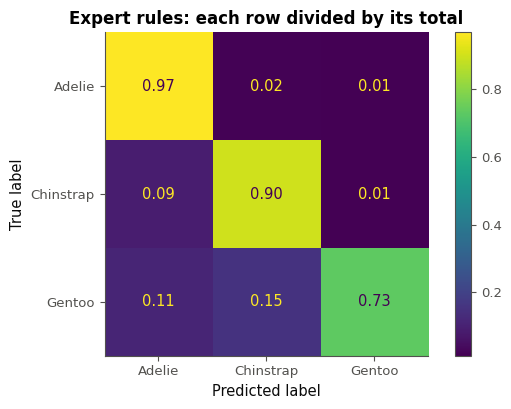

0.7317073170731707 0.8541386666295269 0.8670522807041978


In [36]:
print(skm.classification_report(species, expert_pred, digits=3))
normalize_22 = "true"
display_22 = skm.ConfusionMatrixDisplay.from_predictions(species, expert_pred, normalize=normalize_22, values_format=".2f")
display_22.ax_.grid(False)
plt.title("Expert rules: each row divided by its total")
plt.show()
report_22 = skm.classification_report(species, expert_pred, output_dict=True)
recall_gentoo_22 = report_22["Gentoo"]["recall"]
macro_f1_22 = report_22["macro avg"]["f1-score"]
weighted_f1_22 = report_22["weighted avg"]["f1-score"]
print(recall_gentoo_22, macro_f1_22, weighted_f1_22)

In [37]:
r22 = report_22
wb.record("3.22a", recall_gentoo_22, decimals=3, mistakes={"c'est la precision des Gentoo : le recall est dans la 2ᵉ colonne du rapport": r22["Gentoo"]["precision"],
                                                            "c'est le F1 des Gentoo : le recall est dans la 2ᵉ colonne du rapport": r22["Gentoo"]["f1-score"]})
wb.record("3.22b", macro_f1_22, decimals=3, mistakes={"c'est le F1 pondéré (ligne weighted avg) : on demande la ligne macro avg": r22["weighted avg"]["f1-score"],
                                                       "c'est la precision macro : le F1 est dans la 3ᵉ colonne": r22["macro avg"]["precision"],
                                                       "c'est l'accuracy (qui vaut aussi le F1 micro) : on demande la ligne macro avg": r22["accuracy"]})
wb.record("3.22c", weighted_f1_22, decimals=3, mistakes={"c'est le F1 macro : on demande la ligne weighted avg": r22["macro avg"]["f1-score"],
                                                          "c'est l'accuracy (qui vaut aussi le recall pondéré) : on demande le F1 de la ligne weighted avg": r22["accuracy"]})
wb.record("3.22d", normalize_22, mistakes={"avec \"pred\", chaque COLONNE somme à 1 : la diagonale donne la precision de chaque espèce": "pred",
                                           "avec \"all\", toute la matrice somme à 1 : les cases sont des probabilités jointes": "all"})

WB_ANSWER {"decimals": 3, "hash": "3764805d74a8d0ccf85edc7018247e45cdc7efb2bdf19f940f7e7158eccb0fc0", "hash_coarse": "18a214b9310298727b18b86d7e391b3cec09670cb991b5286ab59d8c0a045eaf", "id": "3.22a", "kind": "float", "magnitude": -1, "mistakes": {"9bf9a6564c95efee152ffe639fa6caa3f38ce30bf2d8c3a6de22eea848eafc7e": "c'est la precision des Gentoo : le recall est dans la 2ᵉ colonne du rapport", "a0a68c2005733151654a2aca2459739eb807d93f850eabbb1734def383c89b83": "c'est le F1 des Gentoo : le recall est dans la 2ᵉ colonne du rapport"}, "sign": 1}
📝 Ex 3.22a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "51f6c9b3fb40eec04383b8a067e6b57ea0a008f2154fd83c7c5e55ce9eae03eb", "hash_coarse": "a3e78dab77fd1866f1561e9e1b932128ad6f312eaa730472d0a0bff39c71323d", "id": "3.22b", "kind": "float", "magnitude": -1, "mistakes": {"1a081e7e461f399e0877f6b2cde44fa2f9acb9513f5291374fe3f6e7a49420d7": "c'est le F1 pondéré (ligne weighted avg) : on demande la ligne macro avg", "3dbf7

💡 `normalize="true"` divise chaque ligne (une vraie espèce) par son total : la diagonale donne le recall de chaque espèce, et l'on voit d'un coup d'œil que 27 % des Gentoo sont manqués. Le F1 macro (0,854) est sous le F1 pondéré (0,867) parce que le Chinstrap, l'espèce au plus petit F1, pèse autant que les autres dans la moyenne macro, mais peu dans la pondérée (68 manchots sur 342). `output_dict=True` sert à récupérer ces chiffres dans du code, pour un tableau de résultats ou un suivi d'expériences.

### Ex 3.23 — Lire la documentation de sklearn.metrics 🛠️ ★★ ⏱️ 25 min
**Objectif :** trouver dans la documentation officielle le comportement exact d'une fonction avant de s'y fier.  
**Prérequis :** Ex 3.22 · fiche (🕰️, « Pour aller plus loin ») · **Parcours :** C

Réflexe professionnel : avant de faire confiance à un chiffre, vérifie **ce que calcule exactement** la fonction. La documentation de chaque fonction de `sklearn.metrics` décrit ses paramètres ; lis-la pour la version du workbook (1.6) : sur le site de scikit-learn, choisis la version en haut de la page, ou, dans le notebook, `help(skm.precision_score)`.

Pour chaque question, **prévois** la réponse en lisant la documentation, sans exécuter l'appel ; écris-la dans la variable, puis exécute la vérification, qui compare ta prévision au comportement réel de scikit-learn.
a) `zero_division` : que renvoie `skm.precision_score([1, 1, 0], [0, 0, 0], zero_division=1)` ? (un nombre)
b) `labels` : que renvoie `skm.confusion_matrix(["a", "b", "c", "a"], ["a", "c", "b", "a"], labels=["a", "b"])` ? (une liste de listes) Que deviennent les échantillons dont un label n'est pas dans `labels` ? Ta `confusion_matrix` fait autrement : comment, et pourquoi ?
c) `pos_label` : quelle erreur lève `skm.recall_score(["spam", "ham", "spam"], ["spam", "spam", "ham"])` ? (son nom, une chaîne comme `"KeyError"`)
d) `normalize` : avec `skm.confusion_matrix(y_true, y_pred, normalize="pred")`, qu'est-ce qui somme à 1 : les `"lignes"`, les `"colonnes"` ou `"tout"` ?
e) `sample_weight` : que renvoie `skm.accuracy_score([1, 0, 1], [1, 1, 1], sample_weight=[1, 1, 2])` ? (un nombre)
f) `average=None` : que renvoie `skm.precision_score(["b", "a", "c", "a"], ["b", "a", "a", "c"], average=None)` ? (une liste de nombres) Dans quel ordre sont rangées les classes ?

Dans ta cellule 📝, recopie pour chaque question la phrase de la documentation qui y répond.

In [38]:
answer_23a = 1.0                  # no positive prediction: precision = 0/0, replaced by zero_division
answer_23b = [[2, 0], [0, 0]]     # the samples with a label outside `labels` are left out, silently
answer_23c = "ValueError"         # pos_label=1 (the default) is not one of the labels "spam" and "ham"
answer_23d = "colonnes"           # "pred": each column (a predicted class) is divided by its total
answer_23e = 0.75                 # (1 + 0 + 2) / (1 + 1 + 2): each sample counts with its weight
answer_23f = [0.5, 1.0, 0.0]      # one value per class, in the sorted order of the labels: a, b, c
def numbers_23(value):
    """The numbers of an answer written as a learner would: 0.75, "0,75", "3/4", or lists of them."""
    if isinstance(value, str):
        text = value.strip().replace(",", ".")
        if "/" in text:
            top, bottom = text.split("/")
            return float(top) / float(bottom)
        return float(text)
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        return [numbers_23(item) for item in value]
    return float(value)


WORDS_23 = {"column": "colonnes", "columns": "colonnes", "colonne": "colonnes", "colonnes": "colonnes",
            "row": "lignes", "rows": "lignes", "ligne": "lignes", "lignes": "lignes",
            "all": "tout", "tout": "tout", "toute": "tout", "total": "tout"}


def compare_23(letter, answer, actual, explanation):
    """Compare your prediction with what scikit-learn really does."""
    if answer is ... or answer is None:
        print(f"⏳ Ex 3.23{letter} : pas encore fait.")
        return
    try:
        mine, real = np.asarray(numbers_23(answer), dtype=float), np.asarray(numbers_23(actual), dtype=float)
        ok = mine.shape == real.shape and bool(np.allclose(mine, real))
    except (TypeError, ValueError, ZeroDivisionError):
        def word(text):
            text = str(text).strip().strip("'\"").lower()
            return WORDS_23.get(text, text)
        ok = word(answer) == word(actual)
    verdict(f"3.23{letter}", ok, f"juste ({explanation}).",
            f"scikit-learn donne {actual!r} ({explanation}) : relis la documentation.")


def raised_23(func, *args, **kwargs):
    """Name of the error raised by a scikit-learn call, or "no error"."""
    try:
        func(*args, **kwargs)
    except Exception as error:  # noqa: BLE001 - we want the name of whatever is raised
        return type(error).__name__
    return "no error"


cm_23 = skm.confusion_matrix(["a", "b", "b", "a", "b"], ["a", "b", "a", "a", "a"], normalize="pred")
sums_23 = "colonnes" if np.allclose(cm_23.sum(axis=0), 1) else "lignes" if np.allclose(cm_23.sum(axis=1), 1) else "tout"
compare_23("a", answer_23a, skm.precision_score([1, 1, 0], [0, 0, 0], zero_division=1), "zero_division")
compare_23("b", answer_23b, skm.confusion_matrix(["a", "b", "c", "a"], ["a", "c", "b", "a"], labels=["a", "b"]).tolist(), "labels")
compare_23("c", answer_23c, raised_23(skm.recall_score, ["spam", "ham", "spam"], ["spam", "spam", "ham"]), "pos_label")
compare_23("d", answer_23d, sums_23, "normalize")
compare_23("e", answer_23e, skm.accuracy_score([1, 0, 1], [1, 1, 1], sample_weight=[1, 1, 2]), "sample_weight")
compare_23("f", answer_23f, skm.precision_score(["b", "a", "c", "a"], ["b", "a", "a", "c"], average=None).tolist(), "average=None")

✅ Ex 3.23a : juste (zero_division).
✅ Ex 3.23b : juste (labels).
✅ Ex 3.23c : juste (pos_label).
✅ Ex 3.23d : juste (normalize).
✅ Ex 3.23e : juste (sample_weight).
✅ Ex 3.23f : juste (average=None).


💡 Trois comportements à retenir. `labels` peut **écarter des échantillons** sans prévenir : une matrice dont la somme n'est pas le nombre d'échantillons doit alerter (`mylearn` préfère lever une erreur). `zero_division` fixe la valeur d'une mesure indéfinie (0/0) ; sans lui, scikit-learn renvoie 0 avec un avertissement. `average=None` range les classes dans l'ordre **trié** des labels (ou dans l'ordre de `labels`) : ne suppose jamais l'ordre d'apparition. Pour lire la documentation de la bonne version : le sélecteur de version du site, ou `help()` dans le notebook, qui montre toujours la version installée.

## Partie D · Au-delà du livre : courbes, moyennes, calibration, défi

Sections « au-delà du livre » de la fiche. Tu programmes la courbe ROC et son aire (3.24), les moyennes sur plusieurs classes (3.25), la courbe precision-recall et l'average precision (3.26), puis la calibration (3.28) ; tu apprends à lire ces courbes quand la classe positive est rare (3.27), et tu finis par un défi : bloquer 99 % des fraudes avec le moins de fausses alertes possible (3.29).

### Ex 3.24 — Courbe ROC et AUC 🔨 ★★★ ⏱️ 40 min
**Objectif :** programmer la courbe ROC et l'aire sous la courbe, et s'en servir pour comparer des scores.  
**Prérequis :** Ex 3.20 · fiche « Au-delà du livre (1) » (🧮 méthode des trapèzes) · **Fil rouge :** Penguins · **mylearn :** `metrics.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/metrics.py`, mêmes règles qu'en 3.15 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris trois fonctions (lis leurs docstrings) :
- `roc_curve(y_true, y_score, pos_label=1)` → `(fpr, tpr, thresholds)`. Convertis les entrées avec `np.asarray` (une Series pandas peut avoir un index quelconque). Trie les échantillons par score décroissant (`np.argsort(-scores, kind="mergesort")`), cumule les positifs et les négatifs rencontrés (`np.cumsum`), puis ne garde qu'un point par score distinct : des scores égaux forment un seul seuil (fiche, mini-exemple). Ajoute enfin le point de départ $(0, 0)$, de seuil `np.inf` ;
- `auc(x, y)` : l'aire par la méthode des trapèzes (fiche, 🧮), que les `x` soient croissants ou décroissants ;
- `roc_auc(y_true, y_score, pos_label=1)`, qui réutilise les deux autres.

Vérifications, pour « Gentoo contre le reste » (`is_gentoo`, comme en 3.20) :
a) l'AUC de chacune des quatre mesures de `MEASURES` prise comme score, calculée par ta fonction `roc_auc` (la cellule de vérification l'appelle) ;
b) `best_measure_24` : la mesure qui sépare le mieux les Gentoo des autres, si l'on a le droit de **retourner** un score (prendre son opposé) : son nom, une chaîne ;
c) `auc_minus_depth_24` : l'AUC de l'opposé de l'épaisseur du bec, `-measured["bill_depth_mm"]` (4 décimales), calculée avec ta fonction. Quel lien avec l'AUC de l'épaisseur elle-même ?

La vérification trace les courbes ROC des quatre mesures avec ta fonction, et contrôle sur la nageoire que l'AUC est la probabilité qu'un Gentoo tiré au hasard ait une nageoire plus longue qu'un autre manchot tiré au hasard, un ex-æquo comptant pour moitié (fiche). Puis les tests de ces trois fonctions.

{'bill_length_mm': np.float64(0.794), 'bill_depth_mm': np.float64(0.0122), 'flipper_length_mm': np.float64(0.9956), 'body_mass_g': np.float64(0.9803)}
flipper_length_mm 0.9878420017076882 0.9878420017076883


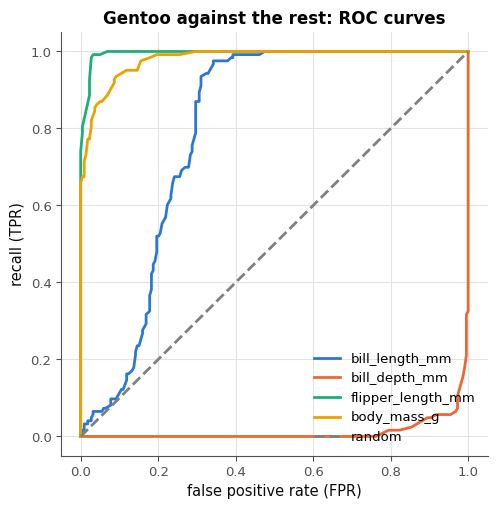

pytest: 33 passed, 197 deselected in 1.19s


In [39]:
aucs_24 = [mylearn.metrics.roc_auc(is_gentoo, measured[measure]) for measure in MEASURES]
print(dict(zip(MEASURES, np.round(aucs_24, 4))))
separation_24 = {measure: max(a, 1 - a) for measure, a in zip(MEASURES, aucs_24)}   # a score may be turned round
best_measure_24 = max(separation_24, key=separation_24.get)
auc_minus_depth_24 = mylearn.metrics.roc_auc(is_gentoo, -measured["bill_depth_mm"])
print(best_measure_24, auc_minus_depth_24, 1 - aucs_24[1])
with wb.attempt("3.24"):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    for measure in MEASURES:
        fpr, tpr, _ = mylearn.metrics.roc_curve(is_gentoo, measured[measure])
        ax.plot(fpr, tpr, label=measure)
    ax.plot([0, 1], [0, 1], ls="--", color="0.5", label="random")
    ax.set(xlabel="false positive rate (FPR)", ylabel="recall (TPR)", title="Gentoo against the rest: ROC curves")
    ax.legend(loc="lower right")
    plt.show()
run_metrics_tests("test_roc_curve_ or test_auc_ or test_roc_auc_", impl="ref")

In [40]:
def untied_auc_24(score):
    """The classic slip: one ROC point per penguin instead of one per distinct score."""
    order = np.argsort(-np.asarray(score, dtype=float), kind="mergesort")
    positive = (is_gentoo == 1)[order]
    tpr = np.r_[0, np.cumsum(positive)] / positive.sum()
    fpr = np.r_[0, np.cumsum(~positive)] / (~positive).sum()
    return float(np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2))


UNTIED_24 = "ta courbe a un point par manchot au lieu d'un point par score distinct : des scores égaux forment un seul seuil (fiche, mini-exemple)"
wb.record("3.24a", aucs_24, decimals=4, mistakes={UNTIED_24: [untied_auc_24(measured[measure]) for measure in MEASURES],
                                                  "tes AUC valent 1 − les bonnes : la courbe part de (0, 0) au seuil +inf, puis les seuils DÉCROISSENT (score >= seuil)": [1 - a for a in aucs_24]})
wb.record("3.24b", best_measure_24, mistakes={"retournée, l'épaisseur du bec sépare bien les Gentoo, mais une autre mesure fait mieux : compare les AUC (ou 1 − AUC)": "bill_depth_mm",
                                              "la masse sépare bien les Gentoo, mais une autre mesure fait mieux : compare les AUC": "body_mass_g"})
wb.record("3.24c", auc_minus_depth_24, decimals=4, mistakes={UNTIED_24: untied_auc_24(-measured["bill_depth_mm"]),
                                                             "c'est l'AUC de l'épaisseur elle-même : on demande celle de son OPPOSÉ (-measured[\"bill_depth_mm\"])": aucs_24[1]})

WB_ANSWER {"decimals": 4, "element_coarse": [["2bec4f092c9577ec42e98ca0b3e480d8273cfe813529c9efce6ba6ce0ac8ced5"], ["cecd5d09641d72ec8d3c280bb2dc7b52cb9207dd26ba83b004d58b410f39b6c4"], ["997979a4cae4a4ae9974a22f1f0de75aa3a71f9dc73ca232a49c2cbad5c78756"], ["d60d682e3c6a189c111cb01460dd862aa437c6091345317047f0b4285f78a5b1"]], "element_hashes": ["a68aaaf9d8303fb97f1b00601fbcc718f44c9662763805bf6b5b808258b7982a", "509eae4d7e59bd6f861fb7f01b68869849c17406acfe843294c4f1bd00bb410c", "fbec5df6d10bed99aaec2bfaca79e7d9f0ed741cb1cc7f51fce220fa9182bb1d", "a71fb7c31ca64817efd3c9aa9362ec7b0a1d55662c123a0125623b259bca818a"], "hash": "3b897be926214b8b6d6921968813a7c93edc2a003b26e40dcfd36c6c862ee5f9", "id": "3.24a", "kind": "array", "mistakes": {"e35d70ac458921c863a89759b1cb8765a2aa4082e417bb3f635e60bcb40feee9": "ta courbe a un point par manchot au lieu d'un point par score distinct : des scores égaux forment un seul seuil (fiche, mini-exemple)", "fc3be940d181c306517b62e0f90fdd3d11665f6d6839d40276d6086

💡 La nageoire range presque parfaitement les Gentoo (AUC 0,996) : un Gentoo tiré au hasard a une nageoire plus longue qu'un autre manchot dans 99,6 % des paires, un ex-æquo comptant pour moitié. L'épaisseur du bec a une AUC de 0,012, bien pire que le hasard… parce que les Gentoo ont le bec le **moins** épais : retournée, elle donne $1 - 0{,}012 = 0{,}988$. Une AUC sous 0,5 signale un score rangé à l'envers, pas un score inutile. La masse (0,980) est bonne aussi ; la longueur du bec (0,794) sépare mal les Gentoo des Chinstrap, qui ont aussi un long bec. L'AUC juge le **classement** sur tous les seuils à la fois ; elle ne dit pas quel seuil choisir (3.20).

### Ex 3.25 — Moyennes macro, micro et pondérée 🔨 ★★★ ⏱️ 35 min
**Objectif :** étendre precision, recall, F-beta et F1 à plusieurs classes, et voir quelle moyenne remarque une classe oubliée.  
**Prérequis :** Ex 3.16, Ex 3.6, Ex 3.15 · Ex 1.15 · fiche « Au-delà du livre : plusieurs classes » · **Fil rouge :** Penguins · **mylearn :** `metrics.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/metrics.py`, mêmes règles qu'en 3.15 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Complète `precision`, `recall`, `fbeta` et `f1` pour les autres valeurs d'`average` (docstrings) :
- `None` : une valeur par classe, chaque classe devenant tour à tour la classe positive (un-contre-tous, *one-vs-rest*), dans l'ordre trié des labels présents dans `y_true` **et** `y_pred`. Ta `confusion_matrix` (3.15) donne tout d'un coup : les TP sur sa diagonale, les FP dans le reste de chaque colonne, les FN dans le reste de chaque ligne ;
- `"macro"` : la moyenne simple des valeurs par classe ; `"weighted"` : leur moyenne pondérée par le support, le nombre de vrais échantillons de chaque classe (`np.average(..., weights=...)`) ;
- `"micro"` : additionne d'abord les TP, les FP et les FN de toutes les classes, puis calcule **une seule** mesure ;
- toute autre valeur d'`average` lève une `ValueError`.

Une classe jamais prédite a une precision 0/0 : c'est `zero_division` qui décide.

Deux classifieurs à trois classes sur les 342 manchots : les règles de la biologiste (`expert_pred`) et une règle à **deux** espèces, `two_species_pred` : « Gentoo » si la nageoire mesure au moins 210 mm, « Adelie » sinon ; elle n'annonce donc jamais « Chinstrap ». Vérifications (la cellule de vérification appelle tes fonctions) :
a) le F1 de chaque espèce pour la règle à deux espèces (`average=None`) ;
b) `[macro, micro, weighted]` du F1 des règles de la biologiste ;
c) la même liste pour la règle à deux espèces ;
d) `most_sensitive_25` : la moyenne qui baisse le plus d'un classifieur à l'autre : `"macro"`, `"micro"` ou `"weighted"`.

La vérification contrôle aussi que le F1 micro vaut l'accuracy (fiche), puis lance les tests des moyennes. Dans tes notes : quand préférer la moyenne macro ? (fiche, E4)

In [41]:
two_species_pred = np.where(flipper >= 210, "Gentoo", "Adelie")   # never answers "Chinstrap"

In [42]:
mm = mylearn.metrics
f1_two_25 = mm.f1(species, two_species_pred, average=None)
averages_expert_25 = [mm.f1(species, expert_pred, average=average) for average in ("macro", "micro", "weighted")]
averages_two_25 = [mm.f1(species, two_species_pred, average=average) for average in ("macro", "micro", "weighted")]
drops_25 = dict(zip(("macro", "micro", "weighted"), np.subtract(averages_expert_25, averages_two_25)))
most_sensitive_25 = max(drops_25, key=drops_25.get)
print("F1 per species (Adelie, Chinstrap, Gentoo):", f1_two_25.round(3))
print("expert:", np.round(averages_expert_25, 3), "· two species:", np.round(averages_two_25, 3), "· drops:",
      {key: round(value, 3) for key, value in drops_25.items()})
run_metrics_tests("(test_precision_ or test_recall_ or test_fbeta_ or test_f1_) and multiclass and not curve", impl="ref")

F1 per species (Adelie, Chinstrap, Gentoo): [0.792 0.    0.92 ]
expert: [0.854 0.868 0.867] · two species: [0.57  0.757 0.68 ] · drops: {'macro': np.float64(0.284), 'micro': np.float64(0.111), 'weighted': np.float64(0.187)}


pytest: 41 passed, 189 deselected in 1.75s


In [43]:
support_25 = [int(np.sum(species == label)) for label in ("Adelie", "Chinstrap", "Gentoo")]
predicted_25 = [int(np.sum(expert_pred == label)) for label in ("Adelie", "Chinstrap", "Gentoo")]
f1_expert_25 = mm.f1(species, expert_pred, average=None)
wb.record("3.25a", f1_two_25, decimals=4, mistakes={"il manque une classe : les labels sont ceux de y_true ET de y_pred, même une classe jamais prédite": [f1_two_25[0], f1_two_25[2]]})
wb.record("3.25b", averages_expert_25, decimals=4, mistakes={"la moyenne pondérée utilise le SUPPORT de chaque classe (ses vrais échantillons, y_true), pas le nombre de ses prédictions": [averages_expert_25[0], averages_expert_25[1], float(np.average(f1_expert_25, weights=predicted_25))]})
wb.record("3.25c", averages_two_25, decimals=4, mistakes={"la moyenne macro compte TOUTES les classes, même celle qui n'est jamais prédite (son F1 vaut 0)": [(f1_two_25[0] + f1_two_25[2]) / 2, averages_two_25[1], averages_two_25[2]]})
wb.record("3.25d", most_sensitive_25, mistakes={"compare les baisses des trois moyennes : dans la pondérée, les Chinstrap ne pèsent que 68 manchots sur 342": "weighted",
                                                "compare les baisses des trois moyennes : la micro, qui vaut l'accuracy, ne regarde pas les classes une par une": "micro"})

WB_ANSWER {"decimals": 4, "element_coarse": [["60764361a04a68c43e45f6b5084f67f81592033326ea3a0a2ec24bd456113c46"], ["0ceb61f0359a5b095eff3c76fe58c3ec49985aa401e2e9a3ad299fdce34d4b6d"], ["c3bf2a1b8b1599894593856f62ef48c8620933191b6eb3419ab8f945dff3cbac"]], "element_hashes": ["07e1d2427c9d93dc4a2c7708efbadffe9e9e4b2d04b95786d9a5aabc1ca9aa90", "734fd25f32b9a1ed744a02c1eda3aff599803da96f18193f97f9d04a78a9c848", "8e4268cbbf6986e1cca84ed365ad726aeed426ce4eb2f5847cc538df11257ba2"], "hash": "92d1140d76bd9c71b0773bc1fce8342f4fcf07a348745ceefa7fd682001935ce", "id": "3.25a", "kind": "array", "mistakes": {"b4fbe612d51a9826db35587341276c17bf95ecfd0d51e6f03cab532a992bde3d": "il manque une classe : les labels sont ceux de y_true ET de y_pred, même une classe jamais prédite"}, "shape": [3]}
📝 Ex 3.25a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "element_coarse": [["974d12a2d8301d27ed20c2a9edcbe8dd22f98c6dda48a458439694173c9f484a"], ["8ebd1ca95ff4438da7a8dfaf7ee89cdf802e91db

💡 La règle à deux espèces est meilleure pour les Gentoo, mais elle ignore une espèce : son F1 Chinstrap vaut 0. La moyenne macro, où chaque espèce compte pour un tiers, s'effondre (de 0,854 à 0,570) ; la pondérée baisse moins (les Chinstrap ne font que 20 % des manchots) ; la micro, qui vaut l'accuracy, baisse le moins. Si chaque classe compte autant (une espèce rare à protéger, une maladie rare), c'est la macro qu'il faut suivre, et toujours avec les scores par classe.

### Ex 3.26 — Courbe precision-recall et average precision 🔨 ★★★ ⏱️ 40 min
**Objectif :** programmer la courbe precision-recall et l'average precision, puis comparer deux modèles selon le nombre d'alertes qu'on peut traiter.  
**Prérequis :** Ex 3.24 · fiche « Au-delà du livre (2) » · **Fil rouge :** synthétique · **mylearn :** `metrics.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/metrics.py`, mêmes règles qu'en 3.15 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `precision_recall_curve(y_true, y_score, pos_label=1)` et `average_precision(y_true, y_score, pos_label=1)` (docstrings). Tu peux reprendre le cœur de ta `roc_curve` (tri par score décroissant, cumuls, un point par score distinct) : une fonction d'aide commune évite de l'écrire deux fois. Attention aux conventions de scikit-learn : les seuils sont rangés par ordre **croissant**, et un dernier point (precision 1, recall 0), sans seuil, ferme la courbe. L'AP est une somme **en escalier** (fiche), pas des trapèzes.

Une équipe antifraude compare deux modèles, A et B, sur 5 000 transactions dont environ 4 % de fraudes (`y_26`, `score_a`, `score_b`).
a) `[AP de A, AP de B]`, calculées par ta fonction `average_precision` (la cellule de vérification l'appelle) ;
b) `top50_26` : la precision de chaque modèle parmi ses 50 transactions les plus suspectes, c'est-à-dire ses 50 plus hauts scores (liste `[A, B]`, 2 décimales) ;
c) `top300_26` : la même chose parmi ses 300 plus hauts scores (3 décimales) ;
d) `choice_26` : l'équipe peut vérifier 300 alertes par jour : quel modèle choisir, `"A"` ou `"B"` ?
e) `auc_26` : `[AUC de A, AUC de B]` (2 décimales), avec ta fonction `roc_auc` de 3.24.

La vérification trace les deux courbes precision-recall avec ta fonction. Dans tes notes : l'AP, l'AUC et le choix de d désignent-ils le même modèle ? Que « voit » chacune de ces mesures ?

In [44]:
rng_26 = np.random.default_rng(26)
y_26 = (rng_26.random(5000) < 0.04).astype(int)           # 1 = fraud, 0 = normal transaction
easy_26 = rng_26.random(5000) < 0.4                       # the frauds that model A recognises at once
score_a = np.where((y_26 == 1) & easy_26, rng_26.normal(4, 0.5, 5000), rng_26.normal(0, 1, 5000) + 0.8 * y_26)
score_b = rng_26.normal(0, 1, 5000) + 2.0 * y_26          # model B: every fraud a little higher
print(f"{y_26.sum()} frauds among {len(y_26)} transactions")

200 frauds among 5000 transactions


AP: [0.502 0.481] · top 50: [1.0, 0.8] · top 300: [0.32, 0.37666666666666665] · AUC: [0.827 0.914]


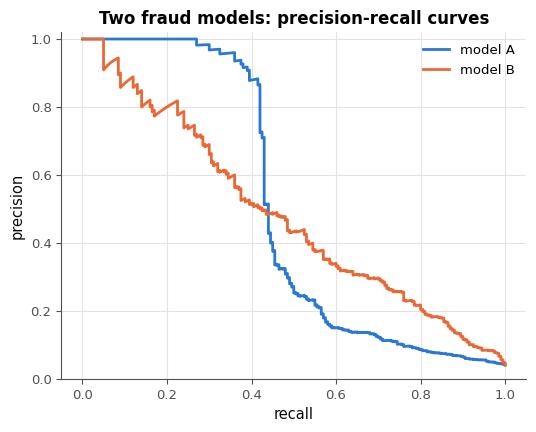

pytest: 26 passed, 204 deselected in 1.04s


In [45]:
def top_precision(y, score, k):
    """Share of frauds among the k highest scores."""
    return float(np.mean(y[np.argsort(-score)[:k]]))


def top_recall(y, score, k):
    """Share of all the frauds found among the k highest scores."""
    return float(np.sum(y[np.argsort(-score)[:k]]) / np.sum(y))


ap_26 = [mylearn.metrics.average_precision(y_26, score) for score in (score_a, score_b)]
top50_26 = [top_precision(y_26, score, 50) for score in (score_a, score_b)]
top300_26 = [top_precision(y_26, score, 300) for score in (score_a, score_b)]
choice_26 = "AB"[int(np.argmax(top300_26))]
auc_26 = [mylearn.metrics.roc_auc(y_26, score) for score in (score_a, score_b)]
print("AP:", np.round(ap_26, 3), "· top 50:", top50_26, "· top 300:", top300_26, "· AUC:", np.round(auc_26, 3))
with wb.attempt("3.26"):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for name, score in [("A", score_a), ("B", score_b)]:
        precision, recall, _ = mylearn.metrics.precision_recall_curve(y_26, score)
        ax.plot(recall, precision, label=f"model {name}")
    ax.set(xlabel="recall", ylabel="precision", title="Two fraud models: precision-recall curves", ylim=(0, 1.02))
    ax.legend()
    plt.show()
run_metrics_tests("test_precision_recall_curve_ or test_average_precision_", impl="ref")

In [46]:
trapezoid_26 = []
for score in (score_a, score_b):
    precision, recall, _ = mylearn.metrics.precision_recall_curve(y_26, score)
    trapezoid_26.append(mylearn.metrics.auc(recall, precision))
wb.record("3.26a", ap_26, decimals=4, mistakes={"tu as relié les points par des trapèzes : l'AP est une somme EN ESCALIER, chaque gain de recall multiplié par la precision atteinte": trapezoid_26,
                                                 "ce sont les AUC des courbes ROC : on demande les AP": auc_26})
wb.record("3.26b", top50_26, decimals=2, mistakes={"l'ordre demandé est [A, B]": top50_26[::-1],
                                                   "ce sont des recalls (part de TOUTES les fraudes trouvées) : on demande la part de fraudes parmi les 50 alertes": [top_recall(y_26, score, 50) for score in (score_a, score_b)]})
wb.record("3.26c", top300_26, decimals=3, mistakes={"l'ordre demandé est [A, B]": top300_26[::-1],
                                                     "ce sont des recalls (part de TOUTES les fraudes trouvées) : on demande la part de fraudes parmi les 300 alertes": [top_recall(y_26, score, 300) for score in (score_a, score_b)]})
wb.record("3.26d", choice_26, mistakes={"compare les precisions parmi 300 alertes (c), pas parmi 50 ni l'AP": "A"})
wb.record("3.26e", auc_26, decimals=2, mistakes={"ce sont les AP : on demande les AUC (roc_auc)": ap_26,
                                                 "l'ordre demandé est [A, B]": auc_26[::-1]})

WB_ANSWER {"decimals": 4, "element_coarse": [["585b60005b8b8bfb63ff36291ea2b409d3a824c232c6e59cf60d12f40e44fc21"], ["61ae75cc58b8fedf91968342896fca6b28df65f550ef5a9642e21c53015fc106"]], "element_hashes": ["5ef90f862d318ab2a920eb655222a23973b2985c7762cd51b852175ef42dbd5e", "a095a2d1a81a0f8943a927d4563598b824de7388722c885ad1df09c31cc26f11"], "hash": "1044f6e7ca075e9deca61340006ba6f1510f5c5a3738277d9c6b2ca3b8fb17fe", "id": "3.26a", "kind": "array", "mistakes": {"6a2c29e4520f12610213b11bf1c77bfd41a5fef1a20f05967ffa8b5b2bbb6b8e": "ce sont les AUC des courbes ROC : on demande les AP", "85c37c01f57a706e4afe6c2ded7e30952220e57d98ef2cef6a6c302ec60e5712": "tu as relié les points par des trapèzes : l'AP est une somme EN ESCALIER, chaque gain de recall multiplié par la precision atteinte"}, "shape": [2]}
📝 Ex 3.26a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 2, "element_coarse": [["77ab052e1830282ad756be158925804be6463ccf27a8efc64da3b1aad4e41aae"], ["3d1f9ccff0baddc573f2a9

💡 Le modèle A repère d'emblée 40 % des fraudes, avec des scores très hauts : ses 50 premières alertes sont toutes des fraudes, et son AP (0,502) dépasse un peu celle de B (0,481), car l'AP pèse surtout le haut de la liste. Mais les autres fraudes, A les voit mal : à 300 alertes, B en trouve davantage (precision 0,377 contre 0,320), et B a une bien meilleure AUC (0,914 contre 0,827), car l'AUC juge le classement dans toute la liste. Aucune mesure résumée ne choisit à ta place : le bon modèle dépend du **point de fonctionnement**, ici le nombre d'alertes que l'équipe peut traiter.

### Ex 3.27 — ROC ou PR ? Lire les courbes d'un problème déséquilibré 📈 ★★ ⏱️ 25 min
**Objectif :** lire des courbes ROC et precision-recall quand la classe positive est rare, et traduire un taux de faux positifs en nombre de fausses alertes.  
**Prérequis :** Ex 3.24 · fiche « Au-delà du livre (1) et (2) » (🕰️ PR et AP) · **Fil rouge :** synthétique · **Parcours :** R, M

Un même modèle (les mêmes lois de scores pour les positifs et pour les négatifs) est évalué sur deux populations de 200 000 cas : l'une compte 2 % de positifs, l'autre 0,5 %. La cellule ci-dessous trace, avec scikit-learn, les courbes ROC (à gauche, puis un zoom sur les petits taux de faux positifs) et precision-recall (à droite). Lis les graphiques, sans recalculer :

a) `same_roc_27` : les deux courbes ROC sont-elles presque confondues ? (`True` ou `False`)
b) `fpr_at_half_27` : sur le zoom, le taux de faux positifs quand le recall (TPR) vaut 0,5 (2 décimales) ;
c) `precision_at_half_27` : sur les courbes precision-recall, la precision quand le recall vaut 0,5, pour 2 % puis pour 0,5 % de positifs (liste, 1 décimale) ;
d) `baseline_27` : la precision d'un classifieur qui répond au hasard, avec 0,5 % de positifs (3 décimales) : à quelle hauteur serait sa « courbe » PR ?
e) `curve_27` : laquelle des deux courbes, `"ROC"` ou `"PR"`, montre que la plupart des alertes seraient fausses avec 0,5 % de positifs ?

Dans tes notes, relie b et c : avec 0,5 % de positifs, combien y a-t-il de négatifs parmi les 200 000 cas, donc combien de fausses alertes au taux lu en b, pour combien de vrais positifs trouvés au recall 0,5 ? Retrouves-tu la precision lue en c ?

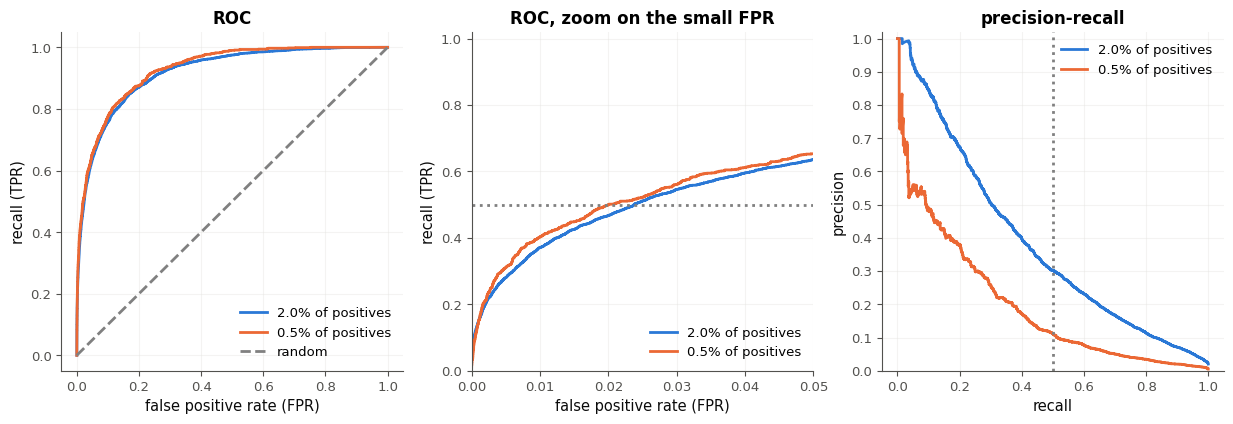

In [47]:
rng_27 = np.random.default_rng(27)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for share, colour in [(0.02, "C0"), (0.005, "C1")]:
    y = rng_27.random(200_000) < share                     # the positives of this population
    score = rng_27.normal(0, 1, 200_000) + 2.0 * y         # the same laws of scores in both populations
    fpr, tpr, _ = skm.roc_curve(y, score)
    precision, recall, _ = skm.precision_recall_curve(y, score)
    label = f"{share:.1%} of positives"
    axes[0].plot(fpr, tpr, color=colour, label=label)
    axes[1].plot(fpr, tpr, color=colour, label=label)
    axes[2].plot(recall, precision, color=colour, label=label)
axes[0].plot([0, 1], [0, 1], ls="--", color="0.5", label="random")
axes[0].set(title="ROC", xlabel="false positive rate (FPR)", ylabel="recall (TPR)")
axes[1].set(title="ROC, zoom on the small FPR", xlabel="false positive rate (FPR)", ylabel="recall (TPR)",
            xlim=(0, 0.05), xticks=np.arange(0, 0.051, 0.01), ylim=(0, 1.02))
axes[1].axhline(0.5, color="0.5", ls=":")
axes[2].set(title="precision-recall", xlabel="recall", ylabel="precision", ylim=(0, 1.02), yticks=np.arange(0, 1.01, 0.1))
axes[2].axvline(0.5, color="0.5", ls=":")
for ax in axes:
    ax.grid(True, alpha=0.4)
    ax.legend(loc="lower right" if ax is not axes[2] else "upper right")
plt.show()

In [48]:
same_roc_27 = True                   # the ROC only uses rates: it ignores the share of positives
fpr_at_half_27 = 0.02                 # read on the zoom, for both populations
precision_at_half_27 = [0.3, 0.1]     # read on the precision-recall curves
baseline_27 = 0.005                   # a random classifier: precision = share of positives
curve_27 = "PR"
negatives, positives = 0.995 * 200_000, 0.005 * 200_000
false_alerts, caught = fpr_at_half_27 * negatives, 0.5 * positives
print(f"{false_alerts:.0f} false alerts for {caught:.0f} positives found: precision ≈ {caught / (caught + false_alerts):.2f}")

3980 false alerts for 500 positives found: precision ≈ 0.11


In [49]:
wb.record("3.27a", same_roc_27, mistakes={"compare les deux courbes du graphique de gauche : l'écart entre elles se voit-il ?": False})
wb.record("3.27b", fpr_at_half_27, decimals=2, mistakes={"c'est le recall : on demande le taux de faux positifs (l'abscisse) au point de recall 0,5": 0.5,
                                                          "c'est la spécificité (1 − FPR) : on demande le FPR lui-même": 0.98})
wb.record("3.27c", precision_at_half_27, decimals=1, mistakes={"l'ordre demandé est [2 %, 0,5 %]": precision_at_half_27[::-1]})
wb.record("3.27d", baseline_27, decimals=3, mistakes={"0,5 est l'AUC de la diagonale de la ROC (le hasard), pas la hauteur de la ligne de base d'une courbe precision-recall (ou bien 0,5 % recopié sans le convertir en proportion) : relis ce que vaut la precision d'alertes tirées au hasard": 0.5,
                                                       "c'est l'autre population : on demande celle à 0,5 % de positifs": 0.02})
wb.record("3.27e", curve_27, mistakes={"sur la ROC, les deux populations donnent la même courbe : elle ne voit pas la part des positifs, donc pas les fausses alertes": "ROC"})

WB_ANSWER {"hash": "a81a91cff1681a3900b64aa87b3501b91c5469bcefc717268570fcf952fb8b95", "id": "3.27a", "kind": "bool", "mistakes": {"d964477253e1dcb464c30e57852b8261cd83562a2a7ed8497b07ea88f8ed9bfb": "compare les deux courbes du graphique de gauche : l'écart entre elles se voit-il ?"}}
📝 Ex 3.27a : réponse enregistrée (bool).
WB_ANSWER {"decimals": 2, "hash": "7aed1fc506d0cc17c340b77041ae08a838e4424a8b5dfe5e16a3266f5a0736a8", "hash_coarse": "e07313c787d0ebba4daf6a99aae56fa52242b085e78b30c3c8f1457f735c26da", "id": "3.27b", "kind": "float", "magnitude": -2, "mistakes": {"2e0aac143f1c2dbca1cfbb62c98ee0fec3b297cfda235c8d6d01adfd037ce791": "c'est la spécificité (1 − FPR) : on demande le FPR lui-même", "3cacdb022f05193bc618839bb6c6b46ed1672c5e38a1900af26563d684fc3eba": "c'est le recall : on demande le taux de faux positifs (l'abscisse) au point de recall 0,5"}, "sign": 1}
📝 Ex 3.27b : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashes": ["80348ae2ac19ae83d25

💡 La ROC n'utilise que des taux (le FPR divise par les négatifs, le recall par les positifs) : elle ne dépend pas de la prévalence, et les deux courbes se confondent. Mais un FPR de 2 % appliqué à 199 000 négatifs fait environ 4 000 fausses alertes, contre 500 positifs trouvés au recall 0,5 : une precision d'environ 0,1, que la courbe PR montre directement. Avec 2 % de positifs, la même lecture donne environ 0,3. D'où le conseil de la fiche : quand la classe positive est rare et que la qualité des alertes compte, montrer la courbe PR (et sa ligne de base, la prévalence) à côté de la ROC.

### Ex 3.28 — Calibration : quand la météo annonce 70 % 🔨 ★★★ ⏱️ 35 min
**Objectif :** programmer le diagramme de fiabilité et le score de Brier, et distinguer calibration et qualité du classement.  
**Prérequis :** Ex 3.16, Ex 2.21 · fiche §3.1 et « Au-delà du livre (3) » · **Fil rouge :** synthétique · **mylearn :** `metrics.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/metrics.py`, mêmes règles qu'en 3.15 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `calibration_curve(y_true, y_prob, n_bins=10)` et `brier_score(y_true, y_prob)` (docstrings). Pour trouver l'intervalle de chaque probabilité, **compare-la aux bords** `edges = np.linspace(0, 1, n_bins + 1)` : `np.searchsorted(edges[1:-1], p)` (ou `np.digitize(p, edges[1:-1], right=True)`) donne le numéro de l'intervalle, une valeur posée sur un bord intérieur allant dans l'intervalle du bas. Ne calcule pas ce numéro par `int(p * n_bins)` : une probabilité posée sur un bord intérieur (0,4 avec 10 intervalles) irait dans l'intervalle du haut au lieu de celui du bas, et $p = 1$ tomberait hors des intervalles ; un test le vérifie. `np.bincount(..., weights=..., minlength=n_bins)` fait ensuite les sommes par intervalle ; ne garde que les intervalles non vides.

Dix ans de prévisions de pluie (3 650 jours) : `rain` vaut 1 les jours de pluie, 0 sinon. Trois prévisionnistes annoncent chaque matin une probabilité de pluie, fabriquée par la cellule ci-dessous : A annonce la vraie probabilité du jour, B la pousse vers 0 ou vers 1, C annonce tous les jours la même valeur, la probabilité moyenne de pluie.
a) `[Brier de A, Brier de B, Brier de C]`, calculés par ta fonction `brier_score` (la cellule de vérification l'appelle) ;
b) `shows_70_28` : une application météo affiche les probabilités arrondies à 10 % : elle affiche « 70 % » quand la prévision est entre 0,65 (inclus) et 0,75 (exclu). Ces jours-là, quelle est la fréquence de la pluie, pour A puis pour B (liste, 3 décimales) ?
c) `auc_28` : `[AUC de A, AUC de B, AUC de C]` (3 décimales), avec ta fonction `roc_auc` de 3.24 ou `skm.roc_auc_score`.

La vérification trace le diagramme de fiabilité des trois prévisionnistes avec ta fonction. Dans tes notes : lequel est calibré ? Lequel est trop sûr de lui, et où le voit-on sur le diagramme ? Lequel est calibré mais inutile, et pourquoi ?

In [50]:
rng_28 = np.random.default_rng(28)
chance_28 = rng_28.beta(1.2, 2.0, 3650)                  # the true chance of rain of each day (known to nobody)
rain = (rng_28.random(3650) < chance_28).astype(int)     # 1 = it rained that day
forecast_a = chance_28                                   # A announces the true chance: honest
forecast_b = 1 / (1 + np.exp(-2.5 * np.log(chance_28 / (1 - chance_28))))   # B pushes it towards 0 or 1
forecast_c = np.full(3650, 0.375)                        # C always announces the average chance of rain
print(f"{rain.sum()} rainy days out of {len(rain)}")

1363 rainy days out of 3650


Brier: [0.18  0.2   0.234] · rain when the app shows 70 %: [0.714 0.575] · AUC: [0.782 0.782 0.5  ]
A announced: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.84 0.93] 
  observed: [0.05 0.15 0.27 0.35 0.44 0.52 0.64 0.73 0.88 0.96]
B announced: [0.03 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.96] 
  observed: [0.16 0.33 0.38 0.46 0.48 0.45 0.58 0.58 0.67 0.82]


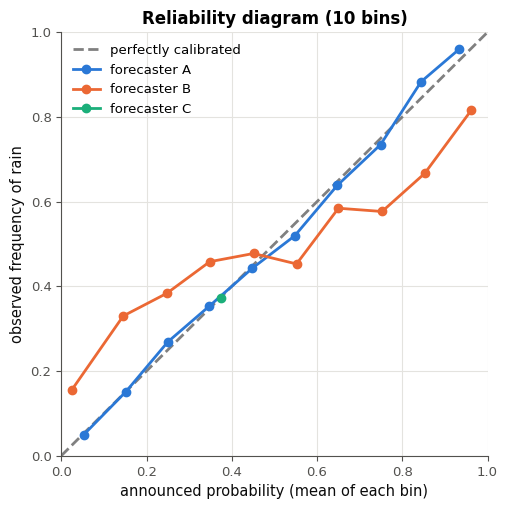

pytest: 19 passed, 211 deselected in 0.97s


In [51]:
brier_28 = [mylearn.metrics.brier_score(rain, forecast) for forecast in (forecast_a, forecast_b, forecast_c)]
shows_70_28 = [float(rain[(forecast >= 0.65) & (forecast < 0.75)].mean()) for forecast in (forecast_a, forecast_b)]
auc_28 = [mylearn.metrics.roc_auc(rain, forecast) for forecast in (forecast_a, forecast_b, forecast_c)]
print("Brier:", np.round(brier_28, 3), "· rain when the app shows 70 %:", np.round(shows_70_28, 3), "· AUC:", np.round(auc_28, 3))
for name, forecast in [("A", forecast_a), ("B", forecast_b)]:
    prob_true, prob_pred = mylearn.metrics.calibration_curve(rain, forecast, n_bins=10)
    print(name, "announced:", prob_pred.round(2), "\n  observed:", prob_true.round(2))
with wb.attempt("3.28"):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot([0, 1], [0, 1], ls="--", color="0.5", label="perfectly calibrated")
    for name, forecast in [("A", forecast_a), ("B", forecast_b), ("C", forecast_c)]:
        prob_true, prob_pred = mylearn.metrics.calibration_curve(rain, forecast, n_bins=10)
        ax.plot(prob_pred, prob_true, marker="o", label=f"forecaster {name}")
    ax.set(xlabel="announced probability (mean of each bin)", ylabel="observed frequency of rain",
           title="Reliability diagram (10 bins)", xlim=(0, 1), ylim=(0, 1))
    ax.legend()
    plt.show()
run_metrics_tests("test_calibration_curve_ or test_brier_score_", impl="ref")

In [52]:
wb.record("3.28a", brier_28, decimals=4, mistakes={"ce sont les racines des scores de Brier : le score de Brier est la moyenne des CARRÉS des écarts, sans racine": list(np.sqrt(brier_28)),
                                                     "tu as fait la moyenne des écarts sans les élever au carré": [float(np.mean(np.abs(forecast - rain))) for forecast in (forecast_a, forecast_b, forecast_c)]})
announced_28 = [float(forecast[(forecast >= 0.65) & (forecast < 0.75)].mean()) for forecast in (forecast_a, forecast_b)]
wb.record("3.28b", shows_70_28, decimals=3, mistakes={"l'ordre demandé est [A, B]": shows_70_28[::-1],
                                                      "ce sont les probabilités annoncées ces jours-là (en moyenne) : on demande la fréquence OBSERVÉE de la pluie": announced_28})
wb.record("3.28c", auc_28, decimals=3, mistakes={"ce sont les scores de Brier : on demande les AUC": brier_28})

WB_ANSWER {"decimals": 4, "element_coarse": [["d6a3ca8224f2e3c1543a3b5c34ecf999b86e20361b590c87025e964dd8e0b004"], ["95b338d030b61c1b20dfaf377621ba6487d55c9c899e423a114b54a81f0763ac"], ["5b0d46a860020bef6d1a8da0bb8cec2929194998b7b6afad490f740d1819b080"]], "element_hashes": ["a518af82ed5642119a9913ab2244ee8e091384ed364d3fa43359a2bb27a610c6", "05ac45fa3639a09100a8206fa9e7e0db025a2f3c9968f9c7cf9eafe30d3e2fe9", "3655a0b76385c1df6487c5c0b081ebb3d0cbaeec9b75952a57023519cd9f7c3b"], "hash": "79f397e4f1391cdeea9bacb1bbb7571f0a2f3003861dca907413dc6606979e23", "id": "3.28a", "kind": "array", "mistakes": {"b98f32f4dbfc6de98287acf6ba068ef31c6a2068356dedee1775ff233c9dcb7d": "tu as fait la moyenne des écarts sans les élever au carré", "fe012d0ed555d67ff6460b78a3b6550758fb5dea9884653716b20ab5921fbb28": "ce sont les racines des scores de Brier : le score de Brier est la moyenne des CARRÉS des écarts, sans racine"}, "shape": [3]}
📝 Ex 3.28a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decim

💡 A suit la diagonale : quand l'application affiche « 70 % », il pleut environ 71 % de ces jours-là. B range les jours exactement dans le même ordre que A (même AUC, 0,782), mais il exagère : les jours où il affiche « 70 % », il ne pleut que 58 % du temps, et sa courbe est plus plate que la diagonale (trop haute à gauche, trop basse à droite). C est parfaitement calibré (un seul point, sur la diagonale) mais inutile : AUC 0,5, il ne distingue aucun jour d'un autre. Le score de Brier les classe A (0,180), B (0,200), C (0,234) : il mélange calibration et classement. B se corrigerait par une recalibration (fiche, 🕰️), sans rien changer à son classement.

### Ex 3.29 — Recall ≥ 0,99 au meilleur prix 🏆 ★★★ ⏱️ 45 min
**Objectif :** choisir, sur un jeu de validation seulement, un modèle et un seuil qui bloquent 99 % des fraudes du jeu de test avec le moins de fausses alertes possible.  
**Prérequis :** Ex 3.26, Ex 3.20 · ch. 2 (percentiles, bootstrap) · fiche §3.7.4, « Au-delà du livre (2) », pièges · **Fil rouge :** synthétique · **Parcours :** C

**Défi.** Une banque exige que son système bloque **au moins 99 %** des fraudes (recall ≥ 0,99). Chaque alerte coûte un appel au client : elle veut aussi **au moins une vraie fraude pour 10 alertes** (precision ≥ 0,10).

Deux modèles, A et B, donnent un score à chaque transaction (1 % de fraudes). Tu disposes d'un jeu de **validation** (`val_29` : 50 000 transactions, colonnes `score_a`, `score_b` et `fraud`) pour faire tes choix, et d'un jeu de **test** (`test_29` : 50 000 autres transactions) qui ne sert qu'à la note finale. Ne le regarde pas pour choisir : régler un seuil sur le test, c'est tricher (fiche, pièges).

Écris `choose_29(val)`, qui reçoit un DataFrame de validation et renvoie `(column, threshold)` : la colonne de score retenue (`"score_a"` ou `"score_b"`) et le seuil (une alerte quand score ≥ seuil). La vérification applique ton choix au jeu de test : il faut un recall ≥ 0,99 **et** une precision ≥ 0,10.

Deux pièges t'attendent :
1. le meilleur modèle selon l'AP n'est pas forcément le meilleur quand il faut attraper presque **toutes** les fraudes : regarde les scores des fraudes les plus basses de chaque modèle ;
2. un seuil qui donne exactement 99 % de recall sur la validation en donne souvent moins sur le test : les fraudes du test ne sont pas celles de la validation, et le 1 % le plus bas d'environ 500 fraudes varie beaucoup d'un tirage à l'autre. Prends une **marge**, mais pas trop grande, sinon la precision s'effondre. Le bootstrap du ch. 2 peut t'aider à mesurer cette variabilité.

Pour aller plus loin, la vérification rejoue ta méthode sur 20 autres couples (validation, test) : combien de fois tient-elle ses deux promesses ?

In [53]:
def make_transactions(n, seed):
    """n transactions, about 1 % of frauds, with the scores of two models A and B."""
    rng = np.random.default_rng(seed)
    fraud = rng.random(n) < 0.01
    kind_2 = rng.random(n) < 0.06
    score_a = rng.normal(0, 1, n) + np.where(fraud & ~kind_2, 5.0, 0.0)
    score_b = rng.normal(0, 1, n) + 4.0 * fraud
    return pd.DataFrame({"score_a": score_a, "score_b": score_b, "fraud": fraud.astype(int)})


def evaluate_29(column, threshold, data):
    """(recall, precision, number of alerts) when we raise an alert for data[column] >= threshold."""
    alert = data[column].to_numpy() >= threshold
    fraud = data["fraud"].to_numpy() == 1
    caught = int(np.sum(alert & fraud))
    return caught / int(np.sum(fraud)), caught / max(int(np.sum(alert)), 1), int(np.sum(alert))


val_29 = make_transactions(50_000, seed=291)     # to choose the model and the threshold
test_29 = make_transactions(50_000, seed=391)    # only for the final grade: do not look at it to choose
print(f"validation: {val_29['fraud'].sum()} frauds · test: {test_29['fraud'].sum()} frauds (50 000 transactions each)")

validation: 505 frauds · test: 490 frauds (50 000 transactions each)


In [54]:
frauds_val = val_29.loc[val_29["fraud"] == 1]
for column in ["score_a", "score_b"]:
    ap = mylearn.metrics.average_precision(val_29["fraud"], val_29[column])
    lowest = np.sort(frauds_val[column].to_numpy())[:6].round(2)
    print(f"{column}: AP {ap:.3f} · the 6 lowest fraud scores: {lowest}")

exactly_99 = np.sort(frauds_val["score_b"].to_numpy())[int(0.01 * len(frauds_val))]   # at most 1 % of the frauds below
for name, (column, threshold) in {"exactly 99 %, no margin": ("score_b", exactly_99),
                                  "0.5 % quantile": ("score_b", np.quantile(frauds_val["score_b"], 0.005)),
                                  "model A, 0.5 % quantile": ("score_a", np.quantile(frauds_val["score_a"], 0.005))}.items():
    r, p, n = evaluate_29(column, threshold, val_29)
    print(f"{name:<24} validation: recall {r:.4f}, precision {p:.4f}, {n} alerts")


def choose_29(val):
    """(score column, threshold) chosen with the validation DataFrame only."""
    scores = val.loc[val["fraud"] == 1, "score_b"].to_numpy()    # model B: every fraud gets a higher score
    return "score_b", float(np.quantile(scores, 0.005))           # a margin: the 0.5 % quantile, not the 1 % one


with wb.attempt("3.29"):
    choice_29 = choose_29(val_29)
    if not (isinstance(choice_29, (tuple, list)) and len(choice_29) == 2 and choice_29[0] in ("score_a", "score_b")
            and np.ndim(choice_29[1]) == 0 and np.issubdtype(np.asarray(choice_29[1]).dtype, np.number)):
        print(f'❌ Ex 3.29 : choose_29 doit renvoyer un couple (colonne, seuil), comme ("score_b", 0.42), '
              f'pas {choice_29!r}.')
    else:
        column_29, threshold_29 = choice_29
        recall_29, precision_29, alerts_29 = evaluate_29(column_29, threshold_29, test_29)
        print(f"your choice: {column_29}, threshold {threshold_29:.4f} · test set: {alerts_29} alerts, "
              f"recall {recall_29:.4f}, precision {precision_29:.4f}")
        verdict("3.29", recall_29 >= 0.99, "recall ≥ 0,99 sur le test : au moins 99 % des fraudes sont bloquées.",
                "recall < 0,99 sur le test : trop de fraudes passent ; prends plus de marge (ou vérifie le modèle).")
        verdict("3.29", precision_29 >= 0.10, "precision ≥ 0,10 sur le test : au plus 9 fausses alertes par fraude bloquée.",
                "precision < 0,10 sur le test : trop d'alertes ; ta marge est trop grande, ou le modèle n'est pas le bon.")
        held_29 = [evaluate_29(*choose_29(make_transactions(50_000, 1000 + 2 * k)), make_transactions(50_000, 1001 + 2 * k))
                   for k in range(20)]
        print(f"for information, your method on 20 other (validation, test) pairs: recall ≥ 0.99 in "
              f"{sum(r >= 0.99 for r, _, _ in held_29)}, precision ≥ 0.10 in {sum(p >= 0.10 for _, p, _ in held_29)}, "
              f"both in {sum(r >= 0.99 and p >= 0.10 for r, p, _ in held_29)}")

score_a: AP 0.925 · the 6 lowest fraud scores: [-2.35 -1.61 -1.45 -1.37 -1.25 -0.95]
score_b: AP 0.923 · the 6 lowest fraud scores: [1.25 1.33 1.39 1.46 1.48 1.82]
exactly 99 %, no margin  validation: recall 0.9901, precision 0.2293, 2181 alerts
0.5 % quantile           validation: recall 0.9941, precision 0.1171, 4286 alerts
model A, 0.5 % quantile  validation: recall 0.9941, precision 0.0109, 46091 alerts
your choice: score_b, threshold 1.4277 · test set: 4241 alerts, recall 0.9959, precision 0.1151
✅ Ex 3.29 : recall ≥ 0,99 sur le test : au moins 99 % des fraudes sont bloquées.
✅ Ex 3.29 : precision ≥ 0,10 sur le test : au plus 9 fausses alertes par fraude bloquée.
for information, your method on 20 other (validation, test) pairs: recall ≥ 0.99 in 16, precision ≥ 0.10 in 17, both in 13


💡 Le modèle A a la meilleure AP, mais 6 % des fraudes (un nouveau type) ont chez lui des scores de transactions normales : pour en bloquer 99 %, il faudrait alerter sur presque tout (precision ≈ 0,01). B relève le score de **toutes** les fraudes. Avec B, un seuil qui garde exactement 99 % des fraudes de validation n'en garde que 98,8 % sur le test : il faut une marge. Le quantile à 0,5 % tient ici (recall 0,996, precision 0,115), mais seulement dans 13 des 20 autres couples. Plus stable : estimer le bas de la distribution des scores de fraudes à partir de **toutes** les fraudes (moyenne − 2,58 écarts-types, si cette distribution est à peu près normale : à vérifier sur un histogramme), qui tient 17 fois sur 20. Garantir 99 % à coup sûr est impossible avec 500 fraudes : on annonce une garantie avec sa marge d'erreur.

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu calculer une probabilité conditionnelle dans une table, et dire laquelle de $P(A \mid B)$ ou $P(B \mid A)$ répond à une question ?
2. Sais-tu construire une matrice de confusion, en tirer les mesures, et choisir une mesure et un seuil selon le coût des erreurs ?
3. Sais-tu expliquer pourquoi, quand la maladie est rare, la plupart des résultats positifs d'un très bon test peuvent être faux, et quand montrer une courbe precision-recall plutôt qu'une ROC ?

**Pour aller plus loin** : les pages du *Machine Learning Crash Course* de Google et le guide « Metrics and scoring » de scikit-learn, cités dans la fiche ; l'article de Fawcett (3.11). La suite : le ch. 4 (règle de Bayes), qui passe de $P(\text{positif} \mid \text{malade})$ à $P(\text{malade} \mid \text{positif})$ ; `mylearn.metrics` servira dans tous les chapitres suivants, dès le ch. 7 (classification) et le ch. 8 (choisir un seuil sur un jeu de validation).